# Machine Learning & Advanced Analytics Jaringan Dosen Infokom

1. **Setup & Rebuild Data** load ulang semua data dan bangun graph
2. **Topic Modeling** LDA vs BERTopic untuk menemukan topik riset tiap dosen
3. **Clustering Dosen** K-Means vs Spectral vs HDBSCAN dengan evaluasi metrik
4. **Link Prediction** Heuristic vs Random Forest vs XGBoost untuk prediksi kolaborasi
5. **Dosen Ranking** Composite scoring berbasis PageRank, produktivitas, dan sentralitas
6. **Export Hasil ke Neo4j** simpan label cluster, skor, dan prediksi ke graph database


## 0. Install Library

Install semua library yang dibutuhkan. `scikit-learn` untuk clustering dan klasifikasi, `gensim` untuk LDA, `bertopic` untuk topic modeling berbasis transformer, `hdbscan` untuk density-based clustering, `xgboost` untuk gradient boosting.

In [ ]:
import subprocess, sys

packages = [
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'networkx',
    'scikit-learn', 'gensim', 'xgboost', 'hdbscan',
    'neo4j', 'tqdm', 'umap-learn'
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('Semua library berhasil diinstall.')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import warnings
import re
import json
from collections import Counter
from itertools import combinations

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    roc_auc_score, average_precision_score,
    classification_report
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

import hdbscan
import xgboost as xgb
import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel
from gensim.utils import simple_preprocess

import umap

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#2E4057', '#048A81', '#54C6EB', '#EF946C', '#C4A77D',
           '#7B2D8B', '#E63946', '#2A9D8F', '#E9C46A', '#F4A261']

print('Import selesai.')

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Import selesai.


## FASE 1 Rebuild Data & Graph

Semua preprocessing dari notebook sebelumnya dijalankan ulang di sini agar notebook ini berdiri sendiri (self-contained). Hasilnya adalah `relasi`, `G` (graph kolaborasi), dan `Gcc` (komponen terbesar).

In [4]:
PATH_DOSEN   = 'dosen_infokom_final.csv'
PATH_SCHOLAR = 'dosen_papers_scholar.csv'
PATH_SCOPUS  = 'dosen_papers_scopus.csv'

dosen   = pd.read_csv(PATH_DOSEN)
scholar = pd.read_csv(PATH_SCHOLAR)
scopus  = pd.read_csv(PATH_SCOPUS)

def normalize_name(name):
    if pd.isna(name): return ''
    name = re.sub(r'\s+', ' ', str(name).strip())
    name = re.sub(r'^(Dr\.|Prof\.|Ir\.|Drs\.|Dra\.|S\.T\.|S\.Kom\.|M\.Kom\.|M\.T\.|Ph\.D\.|S\.Pd\.|M\.Pd\.|M\.Si\.|S\.Si\.)', '', name, flags=re.IGNORECASE).strip()
    return re.sub(r',.*', '', name).strip().title()

def clean_journal(j):
    if pd.isna(j): return 'Unknown'
    c = re.sub(r'\d+.*$', '', str(j)).strip().rstrip(',')
    return c if c else 'Unknown'

dosen['nama_norm_clean'] = dosen['nama_norm'].apply(normalize_name)
dosen_set = set(dosen['nama_norm_clean'])

sc = scholar.copy()
sc['Year'] = pd.to_numeric(sc['Year'], errors='coerce')
sc = sc[sc['Year'].between(2000, 2026)].copy()
sc['Year'] = sc['Year'].astype(int)
sc['Journal_clean'] = sc['Journal'].apply(clean_journal)
sc['source_db'] = 'Scholar'
sc['author_list'] = sc['Authors'].apply(lambda s: [] if pd.isna(s) else [normalize_name(a.strip()) for a in str(s).split(',') if a.strip()])
sc['infokom_authors'] = sc['author_list'].apply(lambda l: [a for a in l if a in dosen_set])
sc_d = sc[sc['infokom_authors'].map(len) > 0].copy()

sp = scopus.copy()
sp['Year'] = pd.to_numeric(sp['Year'], errors='coerce').astype('Int64')
sp = sp[sp['Year'].between(2000, 2026)].copy()
sp['Journal_clean'] = sp['Journal'].fillna('Unknown')
sp['source_db'] = 'Scopus'
sp['paper_id'] = 'scopus_' + sp.index.astype(str)
sp['author_list'] = sp['Authors'].apply(lambda s: [] if pd.isna(s) else [normalize_name(a.strip()) for a in str(s).split(';') if a.strip()])
sp['infokom_authors'] = sp['author_list'].apply(lambda l: [a for a in l if a in dosen_set])
sp_d = sp[sp['infokom_authors'].map(len) > 0].copy()

se  = sc_d.explode('infokom_authors')[['citation_id','Title','Year','Journal_clean','infokom_authors','source_db']].rename(columns={'citation_id':'paper_id','infokom_authors':'nama_norm_clean'})
spe = sp_d.explode('infokom_authors')[['paper_id','Title','Year','Journal_clean','infokom_authors','source_db']].rename(columns={'infokom_authors':'nama_norm_clean'})

relasi = pd.concat([se, spe], ignore_index=True)
relasi = relasi[relasi['nama_norm_clean'].notna() & (relasi['nama_norm_clean'].str.strip() != '')].copy()
relasi = relasi.merge(dosen[['nama_norm_clean','prodi','scholar_id','scopus_id']], on='nama_norm_clean', how='left')

pa = relasi.groupby('paper_id')['nama_norm_clean'].apply(list).reset_index()
pa = pa[pa['nama_norm_clean'].map(len) >= 2]
edge_counter = Counter()
for _, row in pa.iterrows():
    for pair in combinations(sorted(set(row['nama_norm_clean'])), 2):
        edge_counter[pair] += 1

G = nx.Graph()
for n in relasi['nama_norm_clean'].unique():
    pv = dosen[dosen['nama_norm_clean'] == n]['prodi'].values
    G.add_node(n, prodi=pv[0] if len(pv) > 0 else 'Unknown')
for (u, v), w in edge_counter.items():
    G.add_edge(u, v, weight=w)

Gcc = G.subgraph(max(nx.connected_components(G), key=len)).copy()

print(f'Data siap.')
print(f'  relasi          : {len(relasi):,} baris')
print(f'  Dosen unik      : {relasi["nama_norm_clean"].nunique()}')
print(f'  Paper unik      : {relasi["paper_id"].nunique():,}')
print(f'  Graph G         : {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'  Komponen besar  : {Gcc.number_of_nodes()} nodes, {Gcc.number_of_edges()} edges')

Data siap.
  relasi          : 8,651 baris
  Dosen unik      : 129
  Paper unik      : 6,110
  Graph G         : 129 nodes, 1185 edges
  Komponen besar  : 126 nodes, 1185 edges


Bangun corpus teks per dosen, gabungan judul paper, keyword Scopus, dan abstract Scopus. Corpus ini yang akan digunakan sebagai input topic modeling.

In [5]:
scopus_meta = sp[['paper_id', 'Keywords', 'Abstract']].copy()

relasi_enriched = relasi.merge(scopus_meta, on='paper_id', how='left')

corpus_df = relasi_enriched.groupby('nama_norm_clean').agg(
    titles    = ('Title',    lambda x: ' '.join(x.dropna().astype(str))),
    keywords  = ('Keywords', lambda x: ' '.join(x.dropna().astype(str))),
    abstracts = ('Abstract', lambda x: ' '.join(x.dropna().astype(str)))
).reset_index()

corpus_df['full_corpus'] = (
    corpus_df['titles'] + ' ' +
    corpus_df['keywords'] + ' ' +
    corpus_df['abstracts']
).str.strip()

print(f'Corpus per dosen : {len(corpus_df)} entri')
print(f'Dosen dengan keyword Scopus  : {(corpus_df["keywords"].str.strip() != "").sum()}')
print(f'Dosen dengan abstract Scopus : {(corpus_df["abstracts"].str.strip() != "").sum()}')
print(f'Rata-rata panjang corpus     : {corpus_df["full_corpus"].str.split().apply(len).mean():.0f} kata')

Corpus per dosen : 129 entri
Dosen dengan keyword Scopus  : 111
Dosen dengan abstract Scopus : 112
Rata-rata panjang corpus     : 2818 kata


In [8]:
sample = corpus_df.sample(min(3, len(corpus_df)), random_state=42)

for _, row in sample.iterrows():
    print(row['nama_norm_clean'])
    print(f"  titles   : {row['titles'][:120]}{'...' if len(row['titles']) > 120 else ''}")
    print(f"  keywords : {row['keywords'][:120]}{'...' if len(row['keywords']) > 120 else ''}")
    print(f"  abstracts: {row['abstracts'][:150]}{'...' if len(row['abstracts']) > 150 else ''}")
    print(f"  corpus   : {len(row['full_corpus'].split())} kata")
    print()

Hujjatullah Fazlurrahman
  titles   : Perceived Ease of Use, Personal Innovation, and Intention to Use OVO through Attitude among Generation Z in Surabaya Eva...
  keywords : artificial intelligence; disability support; inclusive education; inclusive support policy; natural language processing ...
  abstracts: Despite inclusive education policies in Southeast Asia, disabled students still face barriers and difficulties. Mainly due to the limited individual s...
  corpus   : 3672 kata

Ervin Yohannes
  titles   : Hyperparameter Analysis of Adam-Optimized Deep Transfer Learning for Indonesian Banknote-Denomination Recognition A Perf...
  keywords : Agriculture; coffee image dataset; computer vision; deep learning; edge AI application; business; cryptocurrency; educat...
  abstracts: Coffee is one of the most popular beverages nowadays. To ensure the quality of coffee beans, farmers must go through a sorting process to distinguish ...
  corpus   : 1804 kata

Belgis Ainatul Iza
  titles   

## FASE 2 Topic Modeling

Topic modeling menemukan topik riset yang tersembunyi di balik kumpulan teks publikasi. Kita compare dua pendekatan:
- **LDA** (Latent Dirichlet Allocation) model probabilistik klasik, cepat, interpretable
- **TF-IDF + SVD (LSA)** alternatif ringan berbasis matrix factorization

Output: setiap dosen mendapat distribusi topik, tahu expert di bidang apa.

### 2.1 Preprocessing Teks

Tokenisasi, hapus stopword bahasa Inggris dan Indonesia, dan hapus kata pendek yang tidak informatif.

In [9]:
STOPWORDS_EN = {
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'by','from','up','about','into','through','during','before','after',
    'above','below','between','each','further','then','once','is','are',
    'was','were','be','been','being','have','has','had','do','does','did',
    'will','would','could','should','may','might','shall','can','this',
    'that','these','those','it','its','as','if','than','so','yet','both',
    'not','no','nor','very','just','also','well','used','using','based',
    'proposed','method','approach','paper','study','research','result',
    'results','performance','system','data','analysis','model','models',
    'show','shows','present','new','high','low','large','small',
    'however','which','when','where','how','what','while','their','they',
    'other','such','some','more','most','many','much','same','different',
    'first','second','third','one','two','three','number',
    'test','tests','testing','evaluate','evaluation','compared','comparison',
    'found','finds','finding','findings','given','known','shown',
    'therefore','thus','hence','although','despite','since','because',
    'without','within','across','over','under','along','our','we','us',
    'them','there','here','make','makes','making','made',
    'various','several','existing','specific','general','overall','total',
}
STOPWORDS_ID = {
    'yang','dan','di','ke','dari','untuk','dengan','pada','dalam','adalah',
    'ini','itu','atau','juga','sudah','saat','setelah','sebagai','oleh',
    'tidak','lebih','dapat','akan','telah','sehingga','antara','terhadap',
    'secara','sangat','bahwa','namun','sebuah','tersebut','para','mereka',
    'serta','ketika','seperti','bagi','agar','maka','yaitu','hingga',
}
ALL_STOPWORDS = STOPWORDS_EN | STOPWORDS_ID

def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())
    tokens = text.split()
    tokens = [t for t in tokens if len(t) > 3 and t not in ALL_STOPWORDS]
    return tokens

corpus_df['tokens'] = corpus_df['full_corpus'].apply(preprocess_text)

all_token_counts = Counter(t for tokens in corpus_df['tokens'] for t in tokens)
token_lengths = corpus_df['tokens'].apply(len)

print(f'Total vocabulary      : {len(all_token_counts):,} kata unik')
print(f'Rata-rata token/dosen : {token_lengths.mean():.0f}')
print(f'Dosen token < 50      : {(token_lengths < 50).sum()} ({(token_lengths < 50).mean()*100:.1f}%)')
print(f'Dosen token < 10      : {(token_lengths < 10).sum()} perlu dicek')
print()
print('Top 20 kata paling sering muncul:')
print(pd.DataFrame(all_token_counts.most_common(20), columns=['kata','frekuensi']).to_string(index=False))

Total vocabulary      : 14,037 kata unik
Rata-rata token/dosen : 1665
Dosen token < 50      : 1 (0.8%)
Dosen token < 10      : 0 perlu dicek

Top 20 kata paling sering muncul:
        kata  frekuensi
    learning       3610
    students       1471
    berbasis       1393
 menggunakan       1212
       media       1072
      sistem       1048
pembelajaran       1008
pengembangan        943
 development        903
     digital        884
   algorithm        814
     student        796
     network        769
   education        745
      skills        705
      metode        701
       siswa        665
optimization        663
    surabaya        626
  technology        620


### 2.2 LDA Latent Dirichlet Allocation

LDA menemukan topik sebagai distribusi kata, dan setiap dokumen (corpus dosen) sebagai campuran topik. Kita coba beberapa nilai K (jumlah topik) dan pilih yang terbaik berdasarkan **coherence score**.

In [10]:
id2word = corpora.Dictionary(corpus_df['tokens'])
id2word.filter_extremes(no_below=2, no_above=0.85)

bow_corpus = [id2word.doc2bow(tokens) for tokens in corpus_df['tokens']]

print(f'Dictionary size setelah filter : {len(id2word):,} kata')

coherence_scores = {}
for n_topics in [5, 7, 10, 12, 15]:
    lda = LdaModel(
        corpus=bow_corpus,
        id2word=id2word,
        num_topics=n_topics,
        random_state=42,
        passes=10,
        alpha='auto',
        per_word_topics=True
    )
    from gensim.models import CoherenceModel
    cm = CoherenceModel(model=lda, texts=corpus_df['tokens'], dictionary=id2word, coherence='c_v')
    coherence_scores[n_topics] = cm.get_coherence()
    print(f'  K={n_topics:2d} | Coherence (C_v) = {coherence_scores[n_topics]:.4f}')

best_k = max(coherence_scores, key=coherence_scores.get)
print(f'\nJumlah topik terbaik : K = {best_k} (coherence = {coherence_scores[best_k]:.4f})')

Dictionary size setelah filter : 8,749 kata
  K= 5 | Coherence (C_v) = 0.4986
  K= 7 | Coherence (C_v) = 0.5226
  K=10 | Coherence (C_v) = 0.5436
  K=12 | Coherence (C_v) = 0.5905
  K=15 | Coherence (C_v) = 0.5171

Jumlah topik terbaik : K = 12 (coherence = 0.5905)


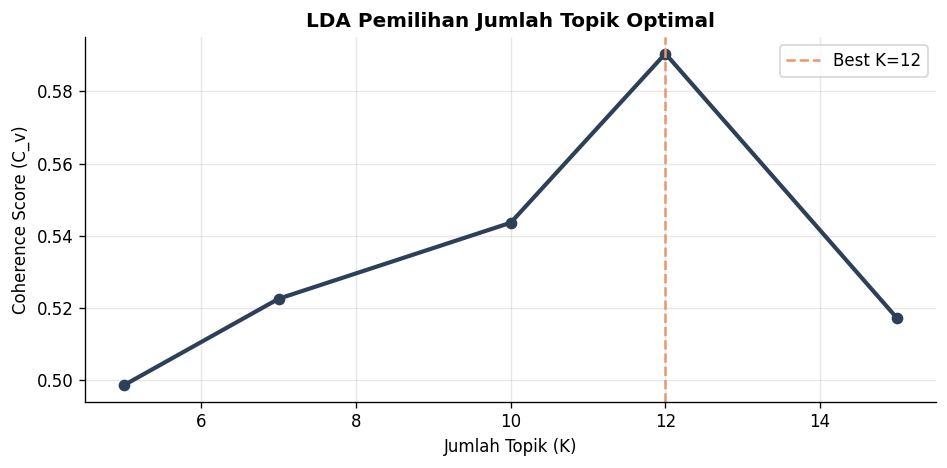

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ks  = list(coherence_scores.keys())
cvs = list(coherence_scores.values())
ax.plot(ks, cvs, marker='o', linewidth=2.5, color=PALETTE[0])
ax.axvline(best_k, color=PALETTE[3], linestyle='--', linewidth=1.5, label=f'Best K={best_k}')
ax.set_xlabel('Jumlah Topik (K)')
ax.set_ylabel('Coherence Score (C_v)')
ax.set_title('LDA Pemilihan Jumlah Topik Optimal', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('ml_plot_01_lda_coherence.png', bbox_inches='tight')
plt.show()

Train model LDA final dengan K terbaik dan ekstrak distribusi topik per dosen.

In [12]:
lda_final = LdaModel(
    corpus=bow_corpus,
    id2word=id2word,
    num_topics=best_k,
    random_state=42,
    passes=20,
    alpha='auto',
    per_word_topics=True
)

print('TOPIK-TOPIK YANG DITEMUKAN LDA')
for i in range(best_k):
    words = lda_final.show_topic(i, topn=8)
    word_str = ', '.join([f'{w}({p:.3f})' for w, p in words])
    print(f'  Topik {i+1:2d}: {word_str}')

TOPIK-TOPIK YANG DITEMUKAN LDA
  Topik  1: menggunakan(0.014), sistem(0.012), metode(0.012), informasi(0.009), information(0.009), berbasis(0.008), analisis(0.008), aplikasi(0.007)
  Topik  2: optimization(0.022), algorithm(0.022), network(0.011), neural(0.010), power(0.009), control(0.009), metaheuristic(0.008), motor(0.008)
  Topik  3: pembelajaran(0.019), berbasis(0.017), pengembangan(0.012), belajar(0.012), mata(0.011), sistem(0.011), menggunakan(0.010), listrik(0.010)
  Topik  4: berbasis(0.021), menggunakan(0.020), aplikasi(0.014), sistem(0.013), metode(0.012), pengembangan(0.009), studi(0.008), rancang(0.007)
  Topik  5: skills(0.013), students(0.012), student(0.008), thinking(0.008), programming(0.006), education(0.006), pembelajaran(0.006), assessment(0.006)
  Topik  6: berbasis(0.020), sistem(0.017), pembelajaran(0.015), menggunakan(0.011), motor(0.010), mata(0.009), pengembangan(0.009), engineering(0.009)
  Topik  7: classification(0.010), students(0.010), accuracy(0.008), m

In [13]:
def get_topic_vector(bow, model, n_topics):
    topic_dist = dict(model.get_document_topics(bow, minimum_probability=0))
    return [topic_dist.get(i, 0.0) for i in range(n_topics)]

topic_vectors = np.array([get_topic_vector(bow, lda_final, best_k) for bow in bow_corpus])

topic_df = pd.DataFrame(
    topic_vectors,
    columns=[f'topic_{i+1}' for i in range(best_k)]
)
topic_df.insert(0, 'nama_norm_clean', corpus_df['nama_norm_clean'].values)
topic_df['dominant_topic'] = topic_vectors.argmax(axis=1) + 1
topic_df['topic_entropy'] = -np.sum(
    topic_vectors * np.log(topic_vectors + 1e-10), axis=1
)

topic_df = topic_df.merge(dosen[['nama_norm_clean','prodi']], on='nama_norm_clean', how='left')

print('=== DISTRIBUSI DOSEN PER DOMINANT TOPIC ===')
print(topic_df['dominant_topic'].value_counts().sort_index().to_string())
print()
print('=== TOP 5 DOSEN DENGAN DIVERSITAS TOPIK TERTINGGI (entropy) ===')
print(topic_df.nlargest(5, 'topic_entropy')[['nama_norm_clean','dominant_topic','topic_entropy','prodi']].to_string(index=False))

=== DISTRIBUSI DOSEN PER DOMINANT TOPIC ===
dominant_topic
1     22
2      5
3      5
4     10
5      4
6      3
7     31
8      9
9      9
10    13
11    16
12     2

=== TOP 5 DOSEN DENGAN DIVERSITAS TOPIK TERTINGGI (entropy) ===
      nama_norm_clean  dominant_topic  topic_entropy                    prodi
        Ari Kurniawan               1         1.7316 D4 Manajemen Informatika
  Moch. Badrus Sholeh               1         1.6495 D4 Manajemen Informatika
         Achmad Fitro               1         1.6193        S1 Bisnis Digital
     Rifqi Firmansyah               8         1.5760        S1 Teknik Elektro
M Adamu Islam Mashuri               7         1.5758 D4 Manajemen Informatika


### 2.3 TF-IDF + SVD (LSA) sebagai Baseline Topic Model

LSA (Latent Semantic Analysis) menggunakan TF-IDF matrix yang didekomposisi dengan SVD. Lebih cepat dari LDA tapi kurang interpretable. Digunakan sebagai fitur alternatif untuk clustering.

In [14]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    stop_words=list(ALL_STOPWORDS)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_df['full_corpus'].fillna(''))

svd = TruncatedSVD(n_components=50, random_state=42)
lsa_vectors = svd.fit_transform(tfidf_matrix)
lsa_vectors_norm = normalize(lsa_vectors)

explained_var = svd.explained_variance_ratio_.cumsum()

print(f'TF-IDF matrix shape  : {tfidf_matrix.shape}')
print(f'LSA vectors shape    : {lsa_vectors.shape}')
print(f'Variance explained   : {explained_var[-1]*100:.1f}% (50 komponen)')
print(f'Variance 10 komponen : {explained_var[9]*100:.1f}%')

TF-IDF matrix shape  : (129, 3000)
LSA vectors shape    : (129, 50)
Variance explained   : 69.9% (50 komponen)
Variance 10 komponen : 29.3%


### 2.4 Visualisasi Topik dengan UMAP

UMAP (Uniform Manifold Approximation and Projection) mereduksi dimensi vektor topik ke 2D agar bisa divisualisasikan. Setiap titik adalah satu dosen, warna berdasarkan topik dominan.

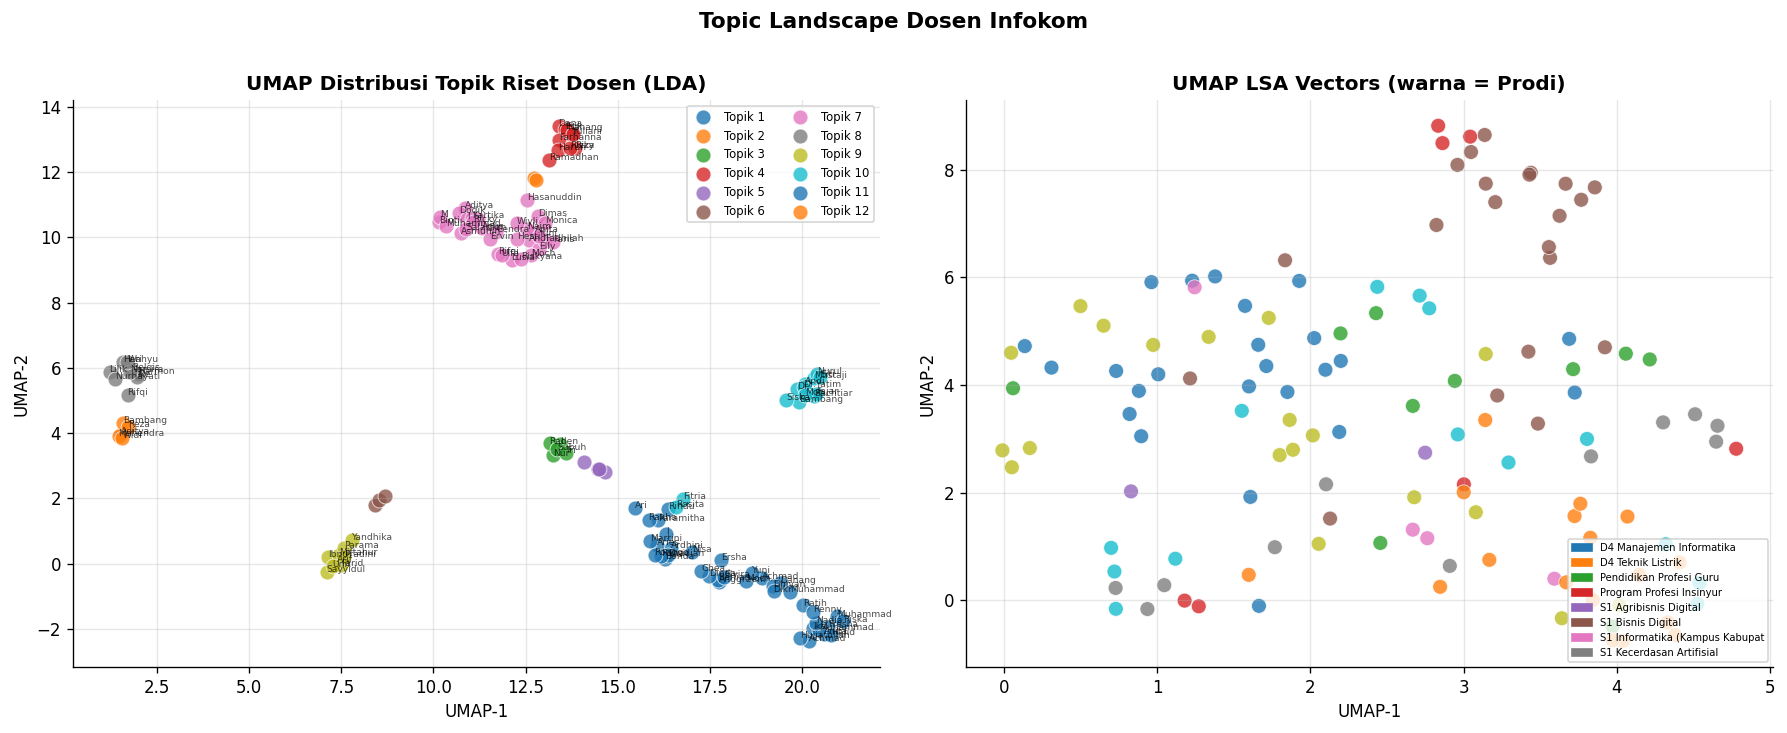

In [15]:
reducer = umap.UMAP(n_neighbors=10, min_dist=0.3, random_state=42, metric='cosine')
umap_2d = reducer.fit_transform(topic_vectors)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors_topic = plt.cm.tab10.colors
for t in range(1, best_k + 1):
    mask = topic_df['dominant_topic'] == t
    axes[0].scatter(
        umap_2d[mask, 0], umap_2d[mask, 1],
        c=[colors_topic[(t-1) % 10]], label=f'Topik {t}',
        s=80, alpha=0.8, edgecolors='white', linewidths=0.5
    )
for i, row in topic_df.iterrows():
    if topic_df['dominant_topic'].value_counts()[row['dominant_topic']] >= 5:
        axes[0].annotate(
            row['nama_norm_clean'].split()[0],
            (umap_2d[i, 0], umap_2d[i, 1]),
            fontsize=5.5, alpha=0.7
        )
axes[0].set_title('UMAP Distribusi Topik Riset Dosen (LDA)', fontweight='bold')
axes[0].legend(fontsize=7, ncol=2)
axes[0].set_xlabel('UMAP-1')
axes[0].set_ylabel('UMAP-2')

reducer2 = umap.UMAP(n_neighbors=10, min_dist=0.3, random_state=42, metric='cosine')
umap_lsa = reducer2.fit_transform(lsa_vectors_norm)

prodi_list  = topic_df['prodi'].fillna('Unknown').tolist()
prodi_uniq  = sorted(set(prodi_list))
prodi_color = {p: colors_topic[i % 10] for i, p in enumerate(prodi_uniq)}
c_prodi     = [prodi_color[p] for p in prodi_list]

axes[1].scatter(umap_lsa[:, 0], umap_lsa[:, 1], c=c_prodi, s=80, alpha=0.8,
                edgecolors='white', linewidths=0.5)
legend_handles = [mpatches.Patch(color=prodi_color[p], label=p[:30]) for p in prodi_uniq[:8]]
axes[1].legend(handles=legend_handles, fontsize=6, ncol=1, loc='lower right')
axes[1].set_title('UMAP LSA Vectors (warna = Prodi)', fontweight='bold')
axes[1].set_xlabel('UMAP-1')
axes[1].set_ylabel('UMAP-2')

plt.suptitle('Topic Landscape Dosen Infokom', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ml_plot_02_umap_topics.png', bbox_inches='tight', dpi=150)
plt.show()

### 2.5 Heatmap Distribusi Topik Top 30 Dosen

Heatmap ini menunjukkan seberapa besar kontribusi setiap topik bagi masing-masing dosen. Warna lebih gelap = topik lebih dominan.

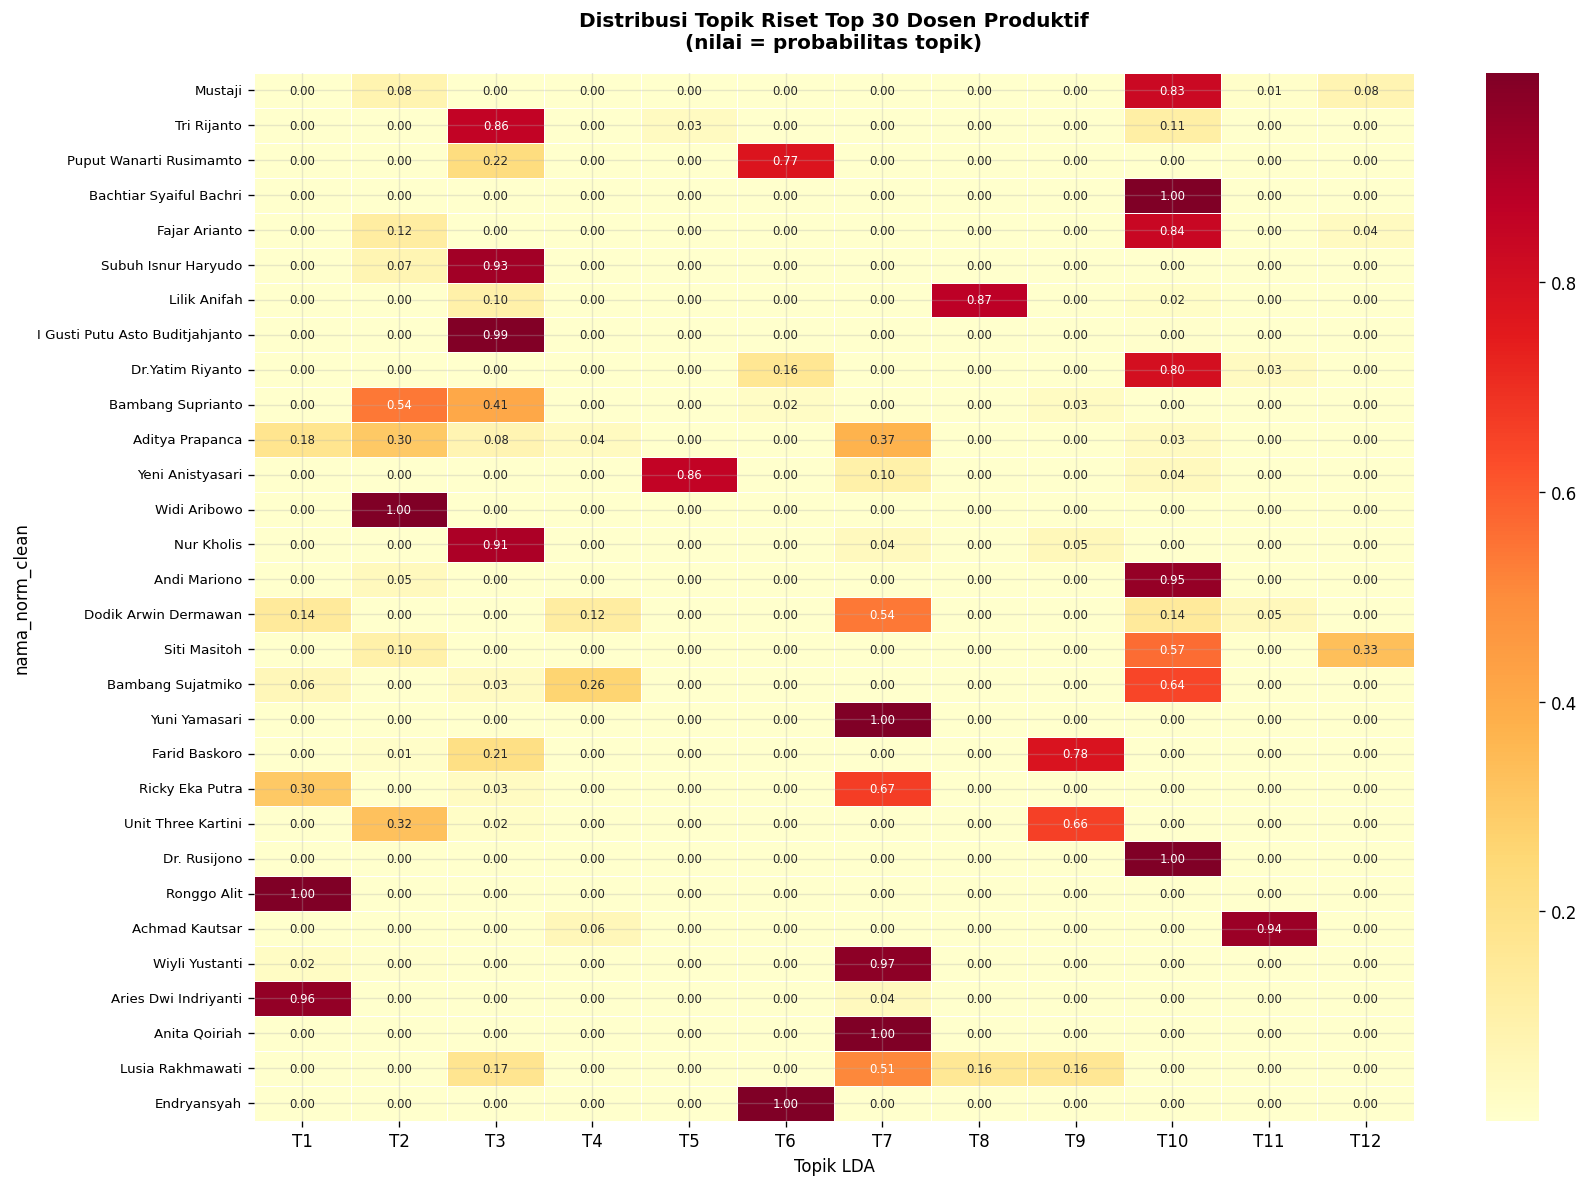

In [16]:
produktivitas = (
    relasi.groupby('nama_norm_clean')['paper_id'].nunique()
    .reset_index(name='total_paper')
    .sort_values('total_paper', ascending=False)
)
top30_names = produktivitas.head(30)['nama_norm_clean'].tolist()

heatmap_df = topic_df[topic_df['nama_norm_clean'].isin(top30_names)].copy()
heatmap_df = heatmap_df.set_index('nama_norm_clean')
topic_cols  = [f'topic_{i+1}' for i in range(best_k)]
heatmap_mat = heatmap_df[topic_cols].reindex(top30_names)

fig, ax = plt.subplots(figsize=(max(10, best_k * 1.2), 10))
sns.heatmap(
    heatmap_mat, ax=ax, cmap='YlOrRd', linewidths=0.3,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    xticklabels=[f'T{i+1}' for i in range(best_k)],
    yticklabels=top30_names
)
ax.set_title('Distribusi Topik Riset Top 30 Dosen Produktif\n(nilai = probabilitas topik)', fontweight='bold', pad=15)
ax.set_xlabel('Topik LDA')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('ml_plot_03_topic_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

## FASE 3 Clustering Dosen

Clustering mengelompokkan dosen berdasarkan kemiripan profil riset DAN posisi dalam jaringan kolaborasi. Kita compare tiga algoritma:
- **K-Means** baseline, cepat, asumsi cluster bulat
- **Spectral Clustering** berbasis graph similarity, cocok untuk jaringan
- **HDBSCAN** density-based, bisa deteksi outlier, tidak perlu tentukan K

Evaluasi menggunakan **Silhouette Score** (makin tinggi makin baik) dan **Davies-Bouldin Index** (makin rendah makin baik).

### 3.1 Bangun Feature Matrix untuk Clustering

Gabungkan dua jenis fitur:

Textual features vektor topik LDA (profil riset)

Structural features metrik graph (degree, betweenness, clustering coefficient, PageRank)

In [17]:
degree_cent  = nx.degree_centrality(Gcc)
betweenness  = nx.betweenness_centrality(Gcc, weight='weight', normalized=True)
closeness    = nx.closeness_centrality(Gcc)
clustering_c = nx.clustering(Gcc, weight='weight')
pagerank     = nx.pagerank(Gcc, weight='weight')
degree_raw   = dict(Gcc.degree(weight='weight'))

graph_metrics = pd.DataFrame({
    'nama_norm_clean' : list(Gcc.nodes()),
    'degree_cent'     : [degree_cent.get(n, 0)  for n in Gcc.nodes()],
    'betweenness'     : [betweenness.get(n, 0)  for n in Gcc.nodes()],
    'closeness'       : [closeness.get(n, 0)    for n in Gcc.nodes()],
    'clustering_c'    : [clustering_c.get(n, 0) for n in Gcc.nodes()],
    'pagerank'        : [pagerank.get(n, 0)      for n in Gcc.nodes()],
    'weighted_degree' : [degree_raw.get(n, 0)   for n in Gcc.nodes()],
})

produktivitas_count = (
    relasi.groupby('nama_norm_clean')['paper_id'].nunique().reset_index(name='total_paper')
)
graph_metrics = graph_metrics.merge(produktivitas_count, on='nama_norm_clean', how='left')
graph_metrics['total_paper'] = graph_metrics['total_paper'].fillna(0)

feature_df = topic_df[['nama_norm_clean'] + [f'topic_{i+1}' for i in range(best_k)] + ['topic_entropy']].merge(
    graph_metrics, on='nama_norm_clean', how='inner'
)

print(f'Feature matrix : {feature_df.shape[0]} dosen x {feature_df.shape[1]-1} fitur')
print('Fitur yang digunakan:')
fitur_cols = [c for c in feature_df.columns if c != 'nama_norm_clean']
for f in fitur_cols:
    print(f'  {f}')

Feature matrix : 126 dosen x 20 fitur
Fitur yang digunakan:
  topic_1
  topic_2
  topic_3
  topic_4
  topic_5
  topic_6
  topic_7
  topic_8
  topic_9
  topic_10
  topic_11
  topic_12
  topic_entropy
  degree_cent
  betweenness
  closeness
  clustering_c
  pagerank
  weighted_degree
  total_paper


In [18]:
feature_cols = [f'topic_{i+1}' for i in range(best_k)] + [
    'topic_entropy', 'degree_cent', 'betweenness', 'closeness',
    'clustering_c', 'pagerank', 'weighted_degree', 'total_paper'
]

X_raw = feature_df[feature_cols].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_norm   = normalize(X_scaled)

dosen_names = feature_df['nama_norm_clean'].tolist()

print(f'X_scaled shape : {X_scaled.shape}')
print('Fitur sudah di-scale (StandardScaler) dan dinormalisasi.')

X_scaled shape : (126, 20)
Fitur sudah di-scale (StandardScaler) dan dinormalisasi.


### 3.2 K-Means Clustering

Jalankan K-Means untuk beberapa nilai K dan pilih yang terbaik berdasarkan Silhouette Score. K-Means bekerja dengan meminimalkan jarak euclidean antara data point dan centroid cluster-nya.

In [19]:
kmeans_results = {}
k_range = range(3, 12)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    labels = km.fit_predict(X_norm)
    sil = silhouette_score(X_norm, labels)
    dbi = davies_bouldin_score(X_norm, labels)
    inertia = km.inertia_
    kmeans_results[k] = {'labels': labels, 'silhouette': sil, 'dbi': dbi, 'inertia': inertia}
    print(f'  K={k:2d} | Silhouette={sil:.4f} | DBI={dbi:.4f} | Inertia={inertia:.1f}')

best_k_km = max(kmeans_results, key=lambda k: kmeans_results[k]['silhouette'])
print(f'\nK-Means terbaik : K={best_k_km} (Silhouette={kmeans_results[best_k_km]["silhouette"]:.4f})')

  K= 3 | Silhouette=0.1584 | DBI=1.9916 | Inertia=92.8
  K= 4 | Silhouette=0.1682 | DBI=1.8093 | Inertia=85.3
  K= 5 | Silhouette=0.1804 | DBI=1.7309 | Inertia=76.8
  K= 6 | Silhouette=0.2038 | DBI=1.6643 | Inertia=70.4
  K= 7 | Silhouette=0.2353 | DBI=1.5797 | Inertia=64.4
  K= 8 | Silhouette=0.2578 | DBI=1.4682 | Inertia=59.3
  K= 9 | Silhouette=0.2738 | DBI=1.4322 | Inertia=54.8
  K=10 | Silhouette=0.2835 | DBI=1.3828 | Inertia=50.4
  K=11 | Silhouette=0.2883 | DBI=1.3325 | Inertia=47.5

K-Means terbaik : K=11 (Silhouette=0.2883)


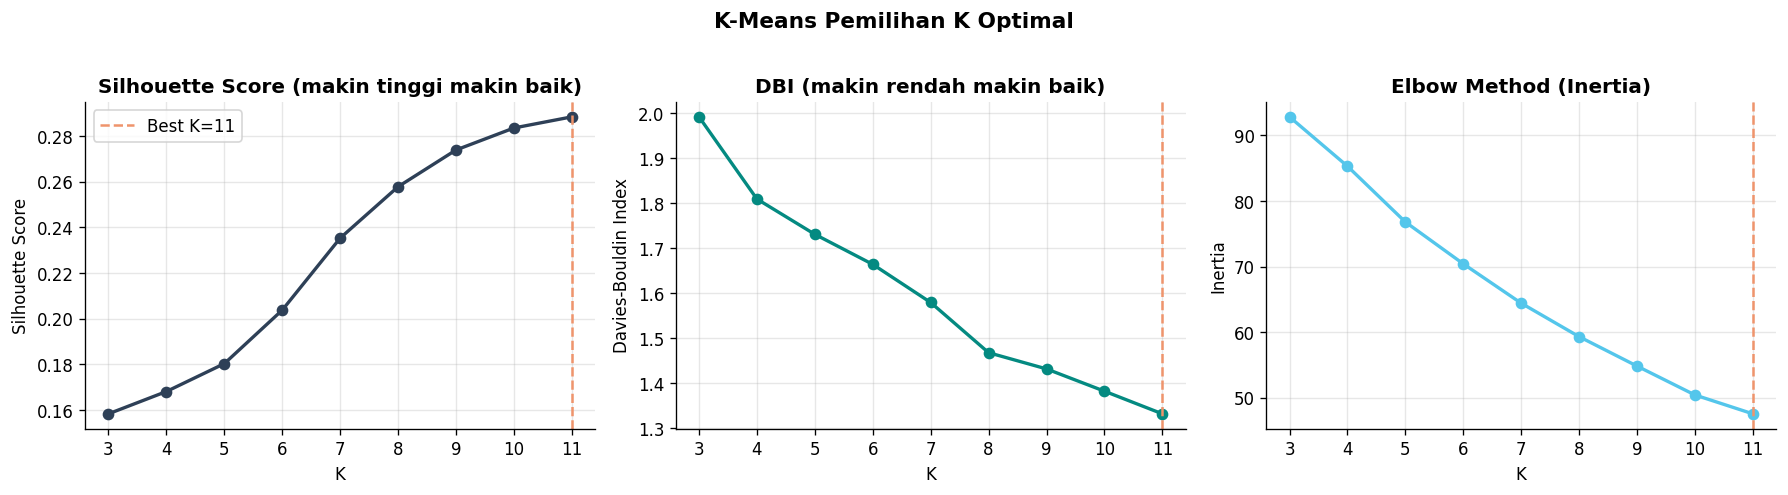

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sihouettes = [kmeans_results[k]['silhouette'] for k in k_range]
dbis       = [kmeans_results[k]['dbi']        for k in k_range]
inertias   = [kmeans_results[k]['inertia']    for k in k_range]

axes[0].plot(list(k_range), sihouettes, marker='o', color=PALETTE[0], linewidth=2)
axes[0].axvline(best_k_km, color=PALETTE[3], linestyle='--', label=f'Best K={best_k_km}')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score (makin tinggi makin baik)', fontweight='bold')
axes[0].legend()

axes[1].plot(list(k_range), dbis, marker='o', color=PALETTE[1], linewidth=2)
axes[1].axvline(best_k_km, color=PALETTE[3], linestyle='--')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_title('DBI (makin rendah makin baik)', fontweight='bold')

axes[2].plot(list(k_range), inertias, marker='o', color=PALETTE[2], linewidth=2)
axes[2].axvline(best_k_km, color=PALETTE[3], linestyle='--')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Inertia')
axes[2].set_title('Elbow Method (Inertia)', fontweight='bold')

plt.suptitle('K-Means Pemilihan K Optimal', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ml_plot_04_kmeans_selection.png', bbox_inches='tight')
plt.show()

### 3.3 Spectral Clustering

Spectral Clustering menggunakan eigenvectors dari adjacency matrix similarity. Cocok untuk data yang tidak berbentuk bulat (non-convex clusters). Di sini kita bangun similarity matrix dari kombinasi fitur tekstual dan struktural.

In [22]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(X_norm)
sim_matrix = np.clip(sim_matrix, 0, 1)

spectral_results = {}
for k in range(3, 12):
    sc_model = SpectralClustering(
        n_clusters=k, affinity='precomputed',
        random_state=42, n_init=10
    )
    labels = sc_model.fit_predict(sim_matrix)
    sil = silhouette_score(X_norm, labels)
    dbi = davies_bouldin_score(X_norm, labels)
    spectral_results[k] = {'labels': labels, 'silhouette': sil, 'dbi': dbi}
    print(f'  K={k:2d} | Silhouette={sil:.4f} | DBI={dbi:.4f}')

best_k_sc = max(spectral_results, key=lambda k: spectral_results[k]['silhouette'])
print(f'\nSpectral terbaik : K={best_k_sc} (Silhouette={spectral_results[best_k_sc]["silhouette"]:.4f})')

  K= 3 | Silhouette=0.1599 | DBI=1.7307
  K= 4 | Silhouette=0.1637 | DBI=1.6931
  K= 5 | Silhouette=0.1839 | DBI=1.5787
  K= 6 | Silhouette=0.2006 | DBI=1.6589
  K= 7 | Silhouette=0.2179 | DBI=1.5596
  K= 8 | Silhouette=0.2321 | DBI=1.4844
  K= 9 | Silhouette=0.2523 | DBI=1.4428
  K=10 | Silhouette=0.2724 | DBI=1.2850
  K=11 | Silhouette=0.2661 | DBI=1.2515

Spectral terbaik : K=10 (Silhouette=0.2724)


### 3.4 HDBSCAN Clustering

HDBSCAN (Hierarchical Density-Based Spatial Clustering) tidak perlu menentukan jumlah cluster di awal. Ia menemukan cluster berdasarkan kepadatan data, dan bisa menandai outlier (dosen yang tidak masuk cluster manapun) dengan label -1.

In [23]:
hdbscan_results = {}
for min_size in [3, 4, 5, 6, 8]:
    hdb = hdbscan.HDBSCAN(min_cluster_size=min_size, metric='euclidean', prediction_data=True)
    labels = hdb.fit_predict(X_norm)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    if n_clusters >= 2:
        mask = labels != -1
        sil = silhouette_score(X_norm[mask], labels[mask]) if mask.sum() > 1 else -1
        dbi = davies_bouldin_score(X_norm[mask], labels[mask]) if mask.sum() > 1 else 999
    else:
        sil, dbi = -1, 999
    hdbscan_results[min_size] = {'labels': labels, 'n_clusters': n_clusters, 'n_noise': n_noise, 'silhouette': sil, 'dbi': dbi}
    print(f'  min_size={min_size} | Clusters={n_clusters} | Noise={n_noise} | Sil={sil:.4f} | DBI={dbi:.4f}')

best_ms = max(hdbscan_results, key=lambda k: hdbscan_results[k]['silhouette'])
print(f'\nHDBSCAN terbaik : min_size={best_ms} (Clusters={hdbscan_results[best_ms]["n_clusters"]}, Silhouette={hdbscan_results[best_ms]["silhouette"]:.4f})')

  min_size=3 | Clusters=12 | Noise=35 | Sil=0.4004 | DBI=0.8719
  min_size=4 | Clusters=9 | Noise=51 | Sil=0.4469 | DBI=0.8525
  min_size=5 | Clusters=5 | Noise=48 | Sil=0.2441 | DBI=1.2413
  min_size=6 | Clusters=3 | Noise=67 | Sil=0.2792 | DBI=1.2134
  min_size=8 | Clusters=2 | Noise=79 | Sil=0.2569 | DBI=1.1065

HDBSCAN terbaik : min_size=4 (Clusters=9, Silhouette=0.4469)


### 3.5 Perbandingan Akhir Semua Algoritma Clustering

Ringkasan perbandingan tiga algoritma dengan konfigurasi terbaik masing-masing.

In [24]:
comparison = pd.DataFrame([
    {
        'Algoritma'       : 'K-Means',
        'Parameter'       : f'K={best_k_km}',
        'Jumlah Cluster'  : best_k_km,
        'Silhouette'      : kmeans_results[best_k_km]['silhouette'],
        'DBI'             : kmeans_results[best_k_km]['dbi'],
        'Noise/Outlier'   : 0,
    },
    {
        'Algoritma'       : 'Spectral Clustering',
        'Parameter'       : f'K={best_k_sc}',
        'Jumlah Cluster'  : best_k_sc,
        'Silhouette'      : spectral_results[best_k_sc]['silhouette'],
        'DBI'             : spectral_results[best_k_sc]['dbi'],
        'Noise/Outlier'   : 0,
    },
    {
        'Algoritma'       : 'HDBSCAN',
        'Parameter'       : f'min_size={best_ms}',
        'Jumlah Cluster'  : hdbscan_results[best_ms]['n_clusters'],
        'Silhouette'      : hdbscan_results[best_ms]['silhouette'],
        'DBI'             : hdbscan_results[best_ms]['dbi'],
        'Noise/Outlier'   : hdbscan_results[best_ms]['n_noise'],
    },
])

print('=== PERBANDINGAN ALGORITMA CLUSTERING ===')
print(comparison.to_string(index=False))

winner = comparison.loc[comparison['Silhouette'].idxmax(), 'Algoritma']
print(f'\nAlgoritma terbaik (Silhouette tertinggi) : {winner}')

=== PERBANDINGAN ALGORITMA CLUSTERING ===
          Algoritma  Parameter  Jumlah Cluster  Silhouette    DBI  Noise/Outlier
            K-Means       K=11              11      0.2883 1.3325              0
Spectral Clustering       K=10              10      0.2724 1.2850              0
            HDBSCAN min_size=4               9      0.4469 0.8525             51

Algoritma terbaik (Silhouette tertinggi) : HDBSCAN


Pilih label cluster terbaik untuk analisis lanjutan dan visualisasi.

In [25]:
best_labels_km  = kmeans_results[best_k_km]['labels']
best_labels_sc  = spectral_results[best_k_sc]['labels']
best_labels_hdb = hdbscan_results[best_ms]['labels']

cluster_df = pd.DataFrame({
    'nama_norm_clean' : dosen_names,
    'cluster_kmeans'  : best_labels_km,
    'cluster_spectral': best_labels_sc,
    'cluster_hdbscan' : best_labels_hdb,
})
cluster_df = cluster_df.merge(dosen[['nama_norm_clean','prodi']], on='nama_norm_clean', how='left')
cluster_df = cluster_df.merge(produktivitas_count, on='nama_norm_clean', how='left')
cluster_df = cluster_df.merge(
    topic_df[['nama_norm_clean','dominant_topic','topic_entropy']],
    on='nama_norm_clean', how='left'
)

print('=== DISTRIBUSI CLUSTER (K-Means) ===')
print(cluster_df['cluster_kmeans'].value_counts().sort_index().to_string())
print()
print('=== DISTRIBUSI CLUSTER (Spectral) ===')
print(cluster_df['cluster_spectral'].value_counts().sort_index().to_string())
print()
print('=== DISTRIBUSI CLUSTER (HDBSCAN) ===')
dist_hdb = cluster_df['cluster_hdbscan'].value_counts().sort_index()
print(dist_hdb.to_string())
if -1 in dist_hdb.index:
    print(f'  (-1 = outlier/noise)')

=== DISTRIBUSI CLUSTER (K-Means) ===
cluster_kmeans
0      5
1      8
2     15
3      8
4     11
5     11
6     16
7     21
8     15
9      9
10     7

=== DISTRIBUSI CLUSTER (Spectral) ===
cluster_spectral
0    17
1    34
2    11
3     4
4    11
5     8
6     7
7     9
8    20
9     5

=== DISTRIBUSI CLUSTER (HDBSCAN) ===
cluster_hdbscan
-1    51
 0     7
 1    10
 2     7
 3    11
 4     5
 5     4
 6    13
 7     9
 8     9
  (-1 = outlier/noise)


### 3.6 Visualisasi Cluster

Tiga plot UMAP menunjukkan hasil clustering dari masing-masing algoritma pada ruang fitur yang sama.

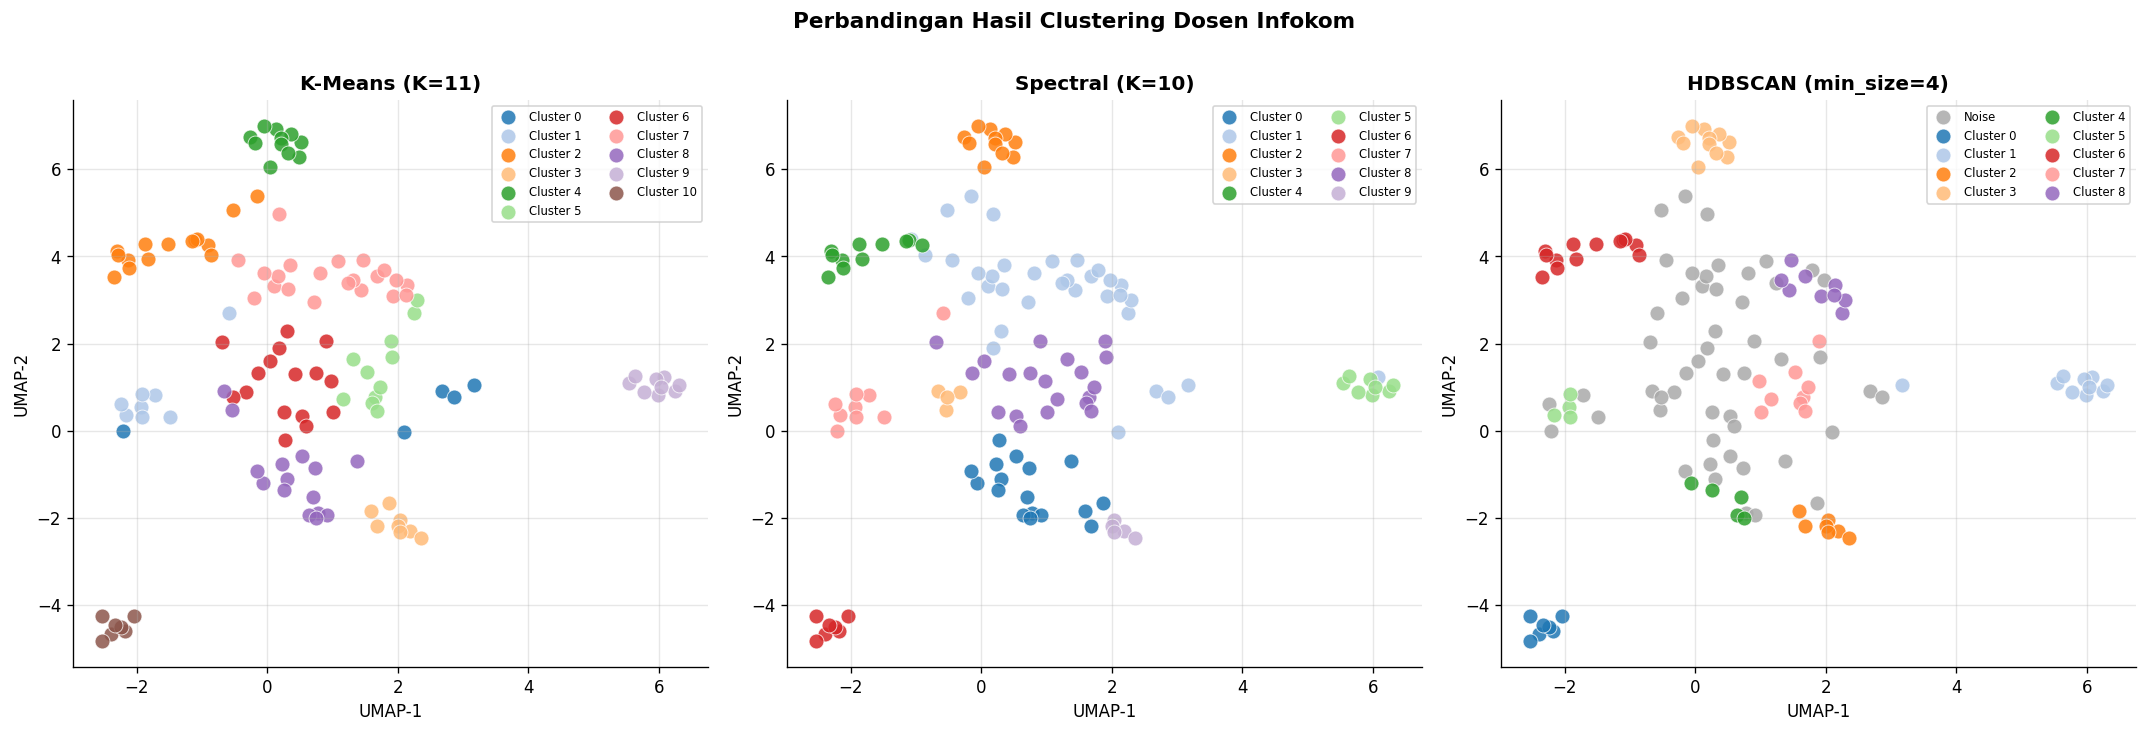

In [26]:
reducer_cl = umap.UMAP(n_neighbors=12, min_dist=0.25, random_state=42, metric='cosine')
umap_cl    = reducer_cl.fit_transform(X_norm)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cmap20 = plt.cm.tab20.colors

def plot_clusters(ax, labels, title):
    unique_labels = sorted(set(labels))
    for lbl in unique_labels:
        mask  = np.array(labels) == lbl
        color = '#AAAAAA' if lbl == -1 else cmap20[lbl % 20]
        label = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(umap_cl[mask, 0], umap_cl[mask, 1], c=[color],
                   label=label, s=80, alpha=0.85, edgecolors='white', linewidths=0.5)
    ax.legend(fontsize=7, ncol=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')

plot_clusters(axes[0], best_labels_km,  f'K-Means (K={best_k_km})')
plot_clusters(axes[1], best_labels_sc,  f'Spectral (K={best_k_sc})')
plot_clusters(axes[2], best_labels_hdb, f'HDBSCAN (min_size={best_ms})')

plt.suptitle('Perbandingan Hasil Clustering Dosen Infokom', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ml_plot_05_cluster_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.7 Profil Tiap Cluster 

Analisis karakteristik setiap cluster rata-rata produktivitas, topik dominan, dan daftar anggota.

In [30]:
cluster_df_profil = cluster_df.merge(
    graph_metrics[['nama_norm_clean','betweenness','pagerank','weighted_degree']],
    on='nama_norm_clean', how='left'
)

def profil_cluster(df, kolom_cluster, label):
    print(f'PROFIL CLUSTER ({label})')
    for cl in sorted(df[kolom_cluster].unique()):
        sub = df[df[kolom_cluster] == cl]
        avg_paper = sub['total_paper'].mean()
        avg_btwn  = sub['betweenness'].mean()
        avg_pr    = sub['pagerank'].mean()
        dom_topic = sub['dominant_topic'].mode()[0] if not sub['dominant_topic'].isna().all() else 'N/A'
        members   = sub['nama_norm_clean'].tolist()
        noise_tag = ' — noise/outlier' if cl == -1 else ''
        print(f'\nCluster {cl}{noise_tag} ({len(sub)} dosen)')
        print(f'  Rata-rata paper       : {avg_paper:.1f}')
        print(f'  Rata-rata betweenness : {avg_btwn:.4f}')
        print(f'  Rata-rata PageRank    : {avg_pr:.5f}')
        print(f'  Dominant topic LDA    : Topik {dom_topic}')
        print(f'  Anggota               : {", ".join(members[:5])}{" ..." if len(members) > 5 else ""}')
    print()

profil_cluster(cluster_df_profil, 'cluster_hdbscan', 'HDBSCAN')

PROFIL CLUSTER (HDBSCAN)

Cluster -1 — noise/outlier (51 dosen)
  Rata-rata paper       : 71.9
  Rata-rata betweenness : 0.0147
  Rata-rata PageRank    : 0.00810
  Dominant topic LDA    : Topik 7
  Anggota               : Achmad Fitro, Aditya Chandra Hermawan, Aditya Prapanca, Andi Iwan Nurhidayat, Ari Kurniawan ...

Cluster 0 (7 dosen)
  Rata-rata paper       : 28.3
  Rata-rata betweenness : 0.0039
  Rata-rata PageRank    : 0.00363
  Dominant topic LDA    : Topik 8
  Anggota               : Belgis Ainatul Iza, Harmon Prayogi, Heri Purnawan, Ike Fitriyaningsih, Namira Roudlotul Jannah ...

Cluster 1 (10 dosen)
  Rata-rata paper       : 43.8
  Rata-rata betweenness : 0.0100
  Rata-rata PageRank    : 0.00493
  Dominant topic LDA    : Topik 4
  Anggota               : Dana Azizah Rahmat, Erik Rahman, Farhanna Mari, Harun Al Rosyid, I Gusti Lanang Putra Eka Prismana ...

Cluster 2 (7 dosen)
  Rata-rata paper       : 67.4
  Rata-rata betweenness : 0.0082
  Rata-rata PageRank    : 0.01005
  

## FASE 4 Link Prediction

Link prediction menjawab pertanyaan: **"Siapa yang berpotensi berkolaborasi di masa depan?"**

Strategi:
1. Buat dataset positif (pasangan yang sudah berkolaborasi) dan negatif (yang belum)
2. Hitung fitur untuk setiap pasangan (graph heuristic + similarity vektor)
3. Latih tiga model: Heuristic baseline, Random Forest, XGBoost
4. Evaluasi dengan AUC-ROC dan Average Precision
5. Output top-N prediksi kolaborasi baru

### 4.1 Bangun Dataset Training

Positive samples = pasangan dosen yang sudah punya edge di Gcc. Negative samples = pasangan yang belum ada edge (non-edges), disampling dengan rasio 1:2.

In [31]:
np.random.seed(42)

pos_edges  = list(Gcc.edges())
all_non_edges = list(nx.non_edges(Gcc))
np.random.shuffle(all_non_edges)
neg_edges  = all_non_edges[:len(pos_edges) * 2]

print(f'Positive samples (existing edges)  : {len(pos_edges)}')
print(f'Negative samples (non-edges)       : {len(neg_edges)}')
print(f'Total training pairs               : {len(pos_edges) + len(neg_edges)}')

name_to_idx = {name: i for i, name in enumerate(dosen_names)}

def get_topic_vec(name):
    idx = name_to_idx.get(name, -1)
    if idx == -1:
        return np.zeros(best_k)
    return topic_vectors[idx]

def get_graph_vec(name):
    row = graph_metrics[graph_metrics['nama_norm_clean'] == name]
    if row.empty:
        return np.zeros(6)
    return row[['degree_cent','betweenness','closeness','clustering_c','pagerank','weighted_degree']].values[0]

print('Fungsi feature extraction siap.')

Positive samples (existing edges)  : 1185
Negative samples (non-edges)       : 2370
Total training pairs               : 3555
Fungsi feature extraction siap.


### 4.2 Feature Engineering untuk Link Prediction

Setiap pasangan (u, v) direpresentasikan oleh:
- **Graph heuristics**: common neighbors, Jaccard coefficient, Adamic-Adar, preferential attachment, resource allocation
- **Topik similarity**: cosine similarity vektor topik LDA
- **Structural similarity**: cosine similarity vektor graph metrics
- **Selisih produktivitas** antara dua dosen

In [32]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

def extract_link_features(u, v, G):
    neighbors_u = set(G.neighbors(u)) if G.has_node(u) else set()
    neighbors_v = set(G.neighbors(v)) if G.has_node(v) else set()

    common_n  = len(neighbors_u & neighbors_v)
    union_n   = len(neighbors_u | neighbors_v)
    jaccard   = common_n / union_n if union_n > 0 else 0

    adamic = sum(
        1 / np.log(G.degree(w) + 1e-10)
        for w in neighbors_u & neighbors_v
        if G.degree(w) > 1
    )

    pref_attach = G.degree(u) * G.degree(v)

    res_alloc = sum(
        1 / G.degree(w)
        for w in neighbors_u & neighbors_v
        if G.degree(w) > 0
    )

    tv_u = get_topic_vec(u).reshape(1, -1)
    tv_v = get_topic_vec(v).reshape(1, -1)
    topic_sim = cos_sim(tv_u, tv_v)[0, 0]

    gv_u = get_graph_vec(u).reshape(1, -1)
    gv_v = get_graph_vec(v).reshape(1, -1)
    graph_sim = cos_sim(gv_u, gv_v)[0, 0] if np.linalg.norm(gv_u) > 0 and np.linalg.norm(gv_v) > 0 else 0

    prod_u = produktivitas_count[produktivitas_count['nama_norm_clean'] == u]['total_paper'].values
    prod_v = produktivitas_count[produktivitas_count['nama_norm_clean'] == v]['total_paper'].values
    prod_u = prod_u[0] if len(prod_u) > 0 else 0
    prod_v = prod_v[0] if len(prod_v) > 0 else 0
    prod_diff = abs(prod_u - prod_v)
    prod_sum  = prod_u + prod_v

    cluster_same_km  = int(
        cluster_df[cluster_df['nama_norm_clean'] == u]['cluster_kmeans'].values[0] ==
        cluster_df[cluster_df['nama_norm_clean'] == v]['cluster_kmeans'].values[0]
    ) if u in cluster_df['nama_norm_clean'].values and v in cluster_df['nama_norm_clean'].values else 0

    return [
        common_n, jaccard, adamic, pref_attach, res_alloc,
        topic_sim, graph_sim, prod_diff, prod_sum, cluster_same_km
    ]

FEATURE_NAMES = [
    'common_neighbors', 'jaccard', 'adamic_adar', 'pref_attachment', 'resource_allocation',
    'topic_similarity', 'graph_similarity', 'prod_diff', 'prod_sum', 'same_cluster_km'
]

print('Mengekstrak fitur untuk semua pasangan')
X_pos = np.array([extract_link_features(u, v, Gcc) for u, v in pos_edges])
X_neg = np.array([extract_link_features(u, v, Gcc) for u, v in neg_edges])

X_link = np.vstack([X_pos, X_neg])
y_link = np.array([1] * len(pos_edges) + [0] * len(neg_edges))

print(f'X_link shape : {X_link.shape}')
print(f'Positif : {y_link.sum()} | Negatif : {(y_link==0).sum()}')

Mengekstrak fitur untuk semua pasangan
X_link shape : (3555, 10)
Positif : 1185 | Negatif : 2370


### 4.3 Heuristic Baseline

Heuristic tidak butuh training. Kita gunakan Adamic-Adar index sebagai score dan evaluasi langsung dengan AUC-ROC.

In [34]:
idx_adamic    = FEATURE_NAMES.index('adamic_adar')
idx_jaccard   = FEATURE_NAMES.index('jaccard')
idx_common    = FEATURE_NAMES.index('common_neighbors')
idx_topic_sim = FEATURE_NAMES.index('topic_similarity')

heuristic_scores = {
    'Adamic-Adar'      : X_link[:, idx_adamic],
    'Jaccard'          : X_link[:, idx_jaccard],
    'Common Neighbors' : X_link[:, idx_common],
    'Topic Similarity' : X_link[:, idx_topic_sim],
}

print('HEURISTIC BASELINE AUC-ROC')
heuristic_auc = {}
for name, scores in heuristic_scores.items():
    auc = roc_auc_score(y_link, scores)
    ap  = average_precision_score(y_link, scores)
    heuristic_auc[name] = auc
    print(f'  {name:<22} | AUC-ROC={auc:.4f} | Avg Precision={ap:.4f}')

HEURISTIC BASELINE AUC-ROC
  Adamic-Adar            | AUC-ROC=0.8545 | Avg Precision=0.7707
  Jaccard                | AUC-ROC=0.8504 | Avg Precision=0.7723
  Common Neighbors       | AUC-ROC=0.8466 | Avg Precision=0.7386
  Topic Similarity       | AUC-ROC=0.5235 | Avg Precision=0.3500


### 4.4 Random Forest

Random Forest adalah ensemble dari decision trees yang dilatih pada subset acak data dan fitur. Memberikan feature importance yang mudah diinterpretasi.

In [35]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_auc_scores = cross_val_score(rf, X_link, y_link, cv=skf, scoring='roc_auc', n_jobs=-1)
rf_ap_scores  = cross_val_score(rf, X_link, y_link, cv=skf, scoring='average_precision', n_jobs=-1)

rf.fit(X_link, y_link)

print('RANDOM FOREST (5-fold CV)')
print(f'  AUC-ROC per fold         : {[f"{s:.4f}" for s in rf_auc_scores]}')
print(f'  AUC-ROC mean ± std       : {rf_auc_scores.mean():.4f} ± {rf_auc_scores.std():.4f}')
print(f'  Avg Precision mean ± std : {rf_ap_scores.mean():.4f} ± {rf_ap_scores.std():.4f}')

RANDOM FOREST (5-fold CV)
  AUC-ROC per fold         : ['0.8723', '0.8648', '0.8450', '0.8683', '0.8697']
  AUC-ROC mean ± std       : 0.8640 ± 0.0098
  Avg Precision mean ± std : 0.7935 ± 0.0235


### 4.5 XGBoost

XGBoost adalah gradient boosting yang membangun tree secara sekuensial, setiap tree memperbaiki kesalahan tree sebelumnya. Umumnya memberikan performa terbaik untuk tabular data.

In [36]:
scale_pos = (y_link == 0).sum() / (y_link == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_auc_scores = cross_val_score(xgb_model, X_link, y_link, cv=skf, scoring='roc_auc', n_jobs=-1)
xgb_ap_scores  = cross_val_score(xgb_model, X_link, y_link, cv=skf, scoring='average_precision', n_jobs=-1)

xgb_model.fit(X_link, y_link)

print('XGBOOST (5-fold CV)')
print(f'  AUC-ROC per fold         : {[f"{s:.4f}" for s in xgb_auc_scores]}')
print(f'  AUC-ROC mean ± std       : {xgb_auc_scores.mean():.4f} ± {xgb_auc_scores.std():.4f}')
print(f'  Avg Precision mean ± std : {xgb_ap_scores.mean():.4f} ± {xgb_ap_scores.std():.4f}')

XGBOOST (5-fold CV)
  AUC-ROC per fold         : ['0.8511', '0.8529', '0.8281', '0.8572', '0.8587']
  AUC-ROC mean ± std       : 0.8496 ± 0.0111
  Avg Precision mean ± std : 0.7784 ± 0.0218


### 4.6 Perbandingan Model & Feature Importance

In [37]:
best_heuristic_name = max(heuristic_auc, key=heuristic_auc.get)

lp_comparison = pd.DataFrame([
    {'Model': best_heuristic_name, 'AUC-ROC': heuristic_auc[best_heuristic_name], 'Avg Precision': average_precision_score(y_link, heuristic_scores[best_heuristic_name]), 'CV': 'None'},
    {'Model': 'Random Forest',     'AUC-ROC': rf_auc_scores.mean(),               'Avg Precision': rf_ap_scores.mean(),  'CV': f'±{rf_auc_scores.std():.4f}'},
    {'Model': 'XGBoost',           'AUC-ROC': xgb_auc_scores.mean(),              'Avg Precision': xgb_ap_scores.mean(), 'CV': f'±{xgb_auc_scores.std():.4f}'},
])

print('PERBANDINGAN MODEL LINK PREDICTION')
print(lp_comparison.to_string(index=False))

best_lp_model_name = lp_comparison.loc[lp_comparison['AUC-ROC'].idxmax(), 'Model']
print(f'\nModel terbaik : {best_lp_model_name}')

PERBANDINGAN MODEL LINK PREDICTION
        Model  AUC-ROC  Avg Precision      CV
  Adamic-Adar   0.8545         0.7707    None
Random Forest   0.8640         0.7935 ±0.0098
      XGBoost   0.8496         0.7784 ±0.0111

Model terbaik : Random Forest


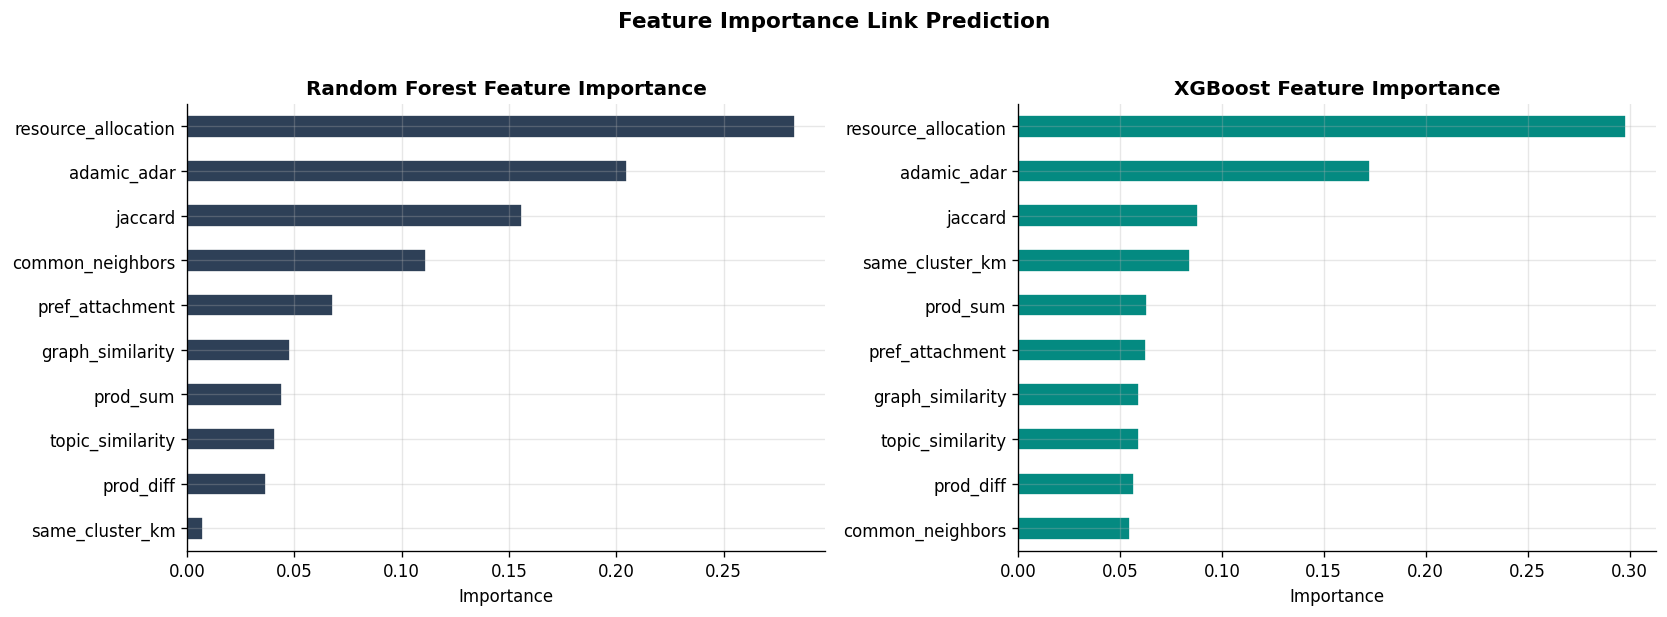

FEATURE IMPORTANCE (XGBoost)
resource_allocation   0.2981
adamic_adar           0.1727
jaccard               0.0885
same_cluster_km       0.0845
prod_sum              0.0633
pref_attachment       0.0626
graph_similarity      0.0595
topic_similarity      0.0592
prod_diff             0.0567
common_neighbors      0.0548


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fi_rf  = pd.Series(rf.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=True)
fi_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=True)

fi_rf.plot(kind='barh', ax=axes[0], color=PALETTE[0], edgecolor='white')
axes[0].set_title('Random Forest Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance')

fi_xgb.plot(kind='barh', ax=axes[1], color=PALETTE[1], edgecolor='white')
axes[1].set_title('XGBoost Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance Link Prediction', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ml_plot_06_feature_importance.png', bbox_inches='tight')
plt.show()

print('FEATURE IMPORTANCE (XGBoost)')
print(fi_xgb.sort_values(ascending=False).to_string())

### 4.7 Top Prediksi Kolaborasi Baru

Gunakan model terbaik untuk memprediksi semua pasangan dosen yang belum berkolaborasi, lalu tampilkan yang memiliki probabilitas kolaborasi tertinggi.

In [39]:
best_lp_model = xgb_model if best_lp_model_name == 'XGBoost' else rf

print('Menghitung prediksi untuk semua non-edge...')
all_non_edges_gcc = list(nx.non_edges(Gcc))

pred_features = np.array([
    extract_link_features(u, v, Gcc) for u, v in all_non_edges_gcc
])

pred_proba = best_lp_model.predict_proba(pred_features)[:, 1]

pred_df = pd.DataFrame({
    'dosen_a'           : [e[0] for e in all_non_edges_gcc],
    'dosen_b'           : [e[1] for e in all_non_edges_gcc],
    'prob_kolaborasi'   : pred_proba,
    'common_neighbors'  : pred_features[:, FEATURE_NAMES.index('common_neighbors')].astype(int),
    'topic_similarity'  : pred_features[:, FEATURE_NAMES.index('topic_similarity')],
    'adamic_adar'       : pred_features[:, FEATURE_NAMES.index('adamic_adar')],
}).sort_values('prob_kolaborasi', ascending=False).reset_index(drop=True)

print('TOP 20 PREDIKSI KOLABORASI BARU')
print(pred_df.head(20).to_string(index=False))

Menghitung prediksi untuk semua non-edge...
TOP 20 PREDIKSI KOLABORASI BARU
                        dosen_a                         dosen_b  prob_kolaborasi  common_neighbors  topic_similarity  adamic_adar
               Rifqi Firmansyah                      Nur Kholis           0.9944                17            0.0002       5.2697
                      Nurhayati                    Widi Aribowo           0.9860                14            0.0003       4.3037
        Puput Wanarti Rusimamto                 Aditya Prapanca           0.9839                18            0.0860       5.3742
            Subuh Isnur Haryudo                   Yuni Yamasari           0.9825                14            0.1154       4.2743
                  Anita Safitri                     Ronggo Alit           0.9824                17            0.0053       5.6543
                   Widi Aribowo                     Endryansyah           0.9797                12            0.8837       3.6289
              

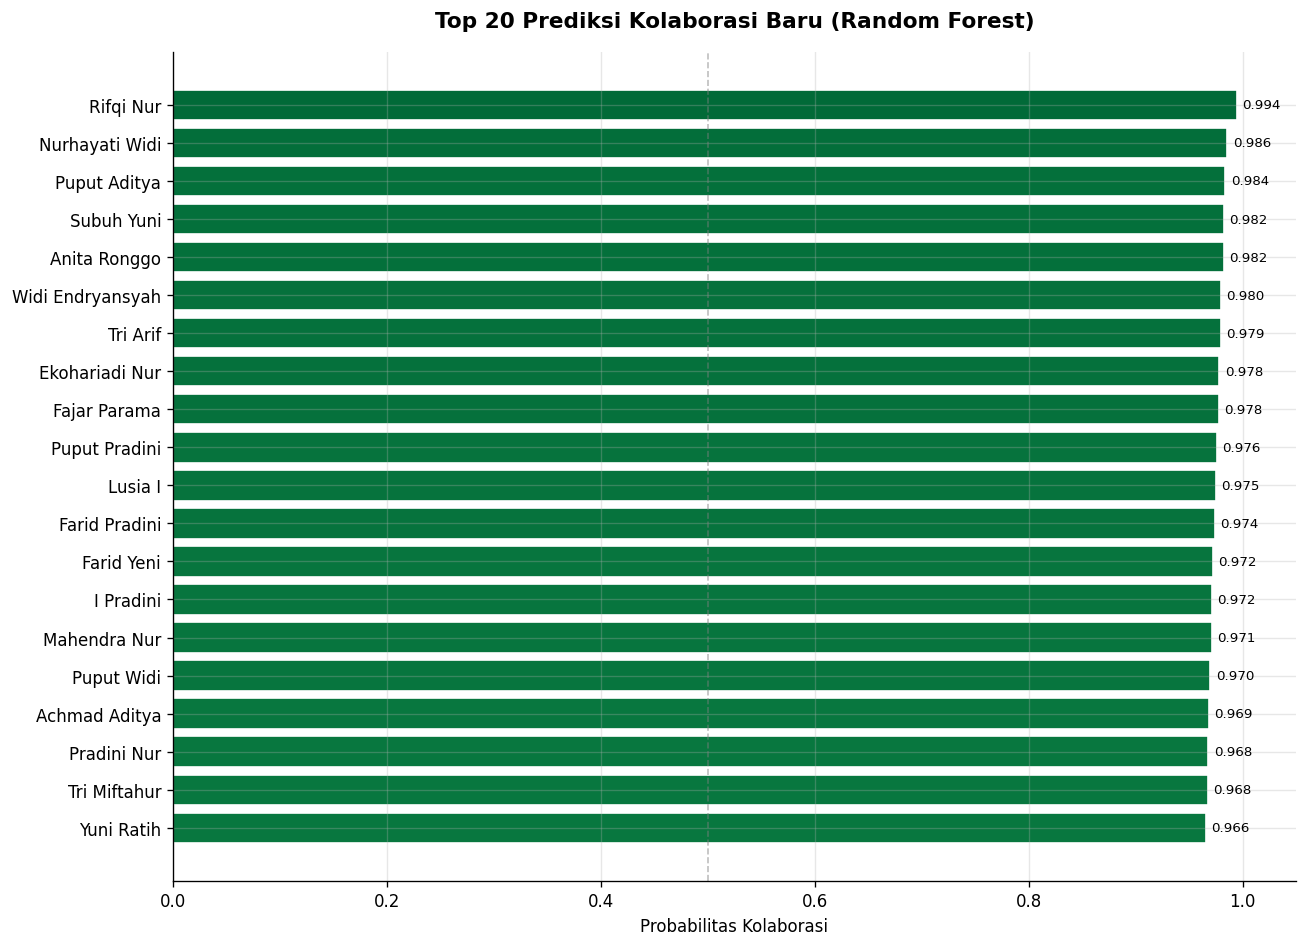

In [40]:
top20_pred = pred_df.head(20)

fig, ax = plt.subplots(figsize=(11, 8))
pair_labels = [f"{row['dosen_a'].split()[0]} {row['dosen_b'].split()[0]}" for _, row in top20_pred.iterrows()]
colors_bar  = plt.cm.RdYlGn(top20_pred['prob_kolaborasi'].values)

bars = ax.barh(pair_labels[::-1], top20_pred['prob_kolaborasi'].values[::-1],
               color=colors_bar[::-1], edgecolor='white')
for bar, val in zip(bars, top20_pred['prob_kolaborasi'].values[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8)

ax.set_xlabel('Probabilitas Kolaborasi')
ax.set_title(f'Top 20 Prediksi Kolaborasi Baru ({best_lp_model_name})', fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, 1.05)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.tight_layout()
plt.savefig('ml_plot_07_link_prediction.png', bbox_inches='tight')
plt.show()

## FASE 5 Dosen Ranking & Composite Scoring

Buat skor tunggal yang merepresentasikan pengaruh dosen secara menyeluruh, menggabungkan empat dimensi:
- **Produktivitas** jumlah paper unik
- **Network Influence** PageRank dalam jaringan kolaborasi
- **Collaboration Reach** betweenness centrality (jadi jembatan)
- **Topic Diversity** entropy distribusi topik riset

In [42]:
ranking_df = cluster_df[['nama_norm_clean','prodi','total_paper','cluster_kmeans']].copy()
ranking_df = ranking_df.merge(
    graph_metrics[['nama_norm_clean','betweenness','pagerank','closeness','weighted_degree','degree_cent']],
    on='nama_norm_clean', how='left'
)
ranking_df = ranking_df.merge(
    topic_df[['nama_norm_clean','topic_entropy','dominant_topic']],
    on='nama_norm_clean', how='left'
)

def minmax(series):
    mn, mx = series.min(), series.max()
    if mx == mn: return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - mn) / (mx - mn)

ranking_df['score_produktivitas'] = minmax(ranking_df['total_paper'].fillna(0))
ranking_df['score_pagerank']      = minmax(ranking_df['pagerank'].fillna(0))
ranking_df['score_betweenness']   = minmax(ranking_df['betweenness'].fillna(0))
ranking_df['score_diversity']     = minmax(ranking_df['topic_entropy'].fillna(0))

W_PROD = 0.30
W_PR   = 0.30
W_BTW  = 0.25
W_DIV  = 0.15

ranking_df['composite_score'] = (
    W_PROD * ranking_df['score_produktivitas'] +
    W_PR   * ranking_df['score_pagerank']      +
    W_BTW  * ranking_df['score_betweenness']   +
    W_DIV  * ranking_df['score_diversity']
)

ranking_df = ranking_df.sort_values('composite_score', ascending=False).reset_index(drop=True)
ranking_df['rank'] = ranking_df.index + 1

print(f'Bobot composite score:')
print(f'  Produktivitas    : {W_PROD*100:.0f}%')
print(f'  PageRank         : {W_PR*100:.0f}%')
print(f'  Betweenness      : {W_BTW*100:.0f}%')
print(f'  Topic Diversity  : {W_DIV*100:.0f}%')
print()
print('TOP 20 DOSEN BERDASARKAN COMPOSITE SCORE')
print(ranking_df.head(20)[[
    'rank','nama_norm_clean','composite_score',
    'score_produktivitas','score_pagerank','score_betweenness','score_diversity','prodi'
]].to_string(index=False))

Bobot composite score:
  Produktivitas    : 30%
  PageRank         : 30%
  Betweenness      : 25%
  Topic Diversity  : 15%

TOP 20 DOSEN BERDASARKAN COMPOSITE SCORE
 rank                 nama_norm_clean  composite_score  score_produktivitas  score_pagerank  score_betweenness  score_diversity                                 prodi
    1                 Aditya Prapanca           0.7488               0.7306          0.9395             0.4838           0.8457                 S1 Teknik Informatika
    2                   Fajar Arianto           0.7097               0.8531          0.7849             0.6895           0.3061               S3 Teknologi Pendidikan
    3         Puput Wanarti Rusimamto           0.6768               0.9020          0.8086             0.4693           0.3083          S2 Pendidikan Teknik Elektro
    4                     Tri Rijanto           0.6625               0.9878          0.6610             0.5011           0.2838 S3 Penelitian dan Evaluasi Pendidikan
    5

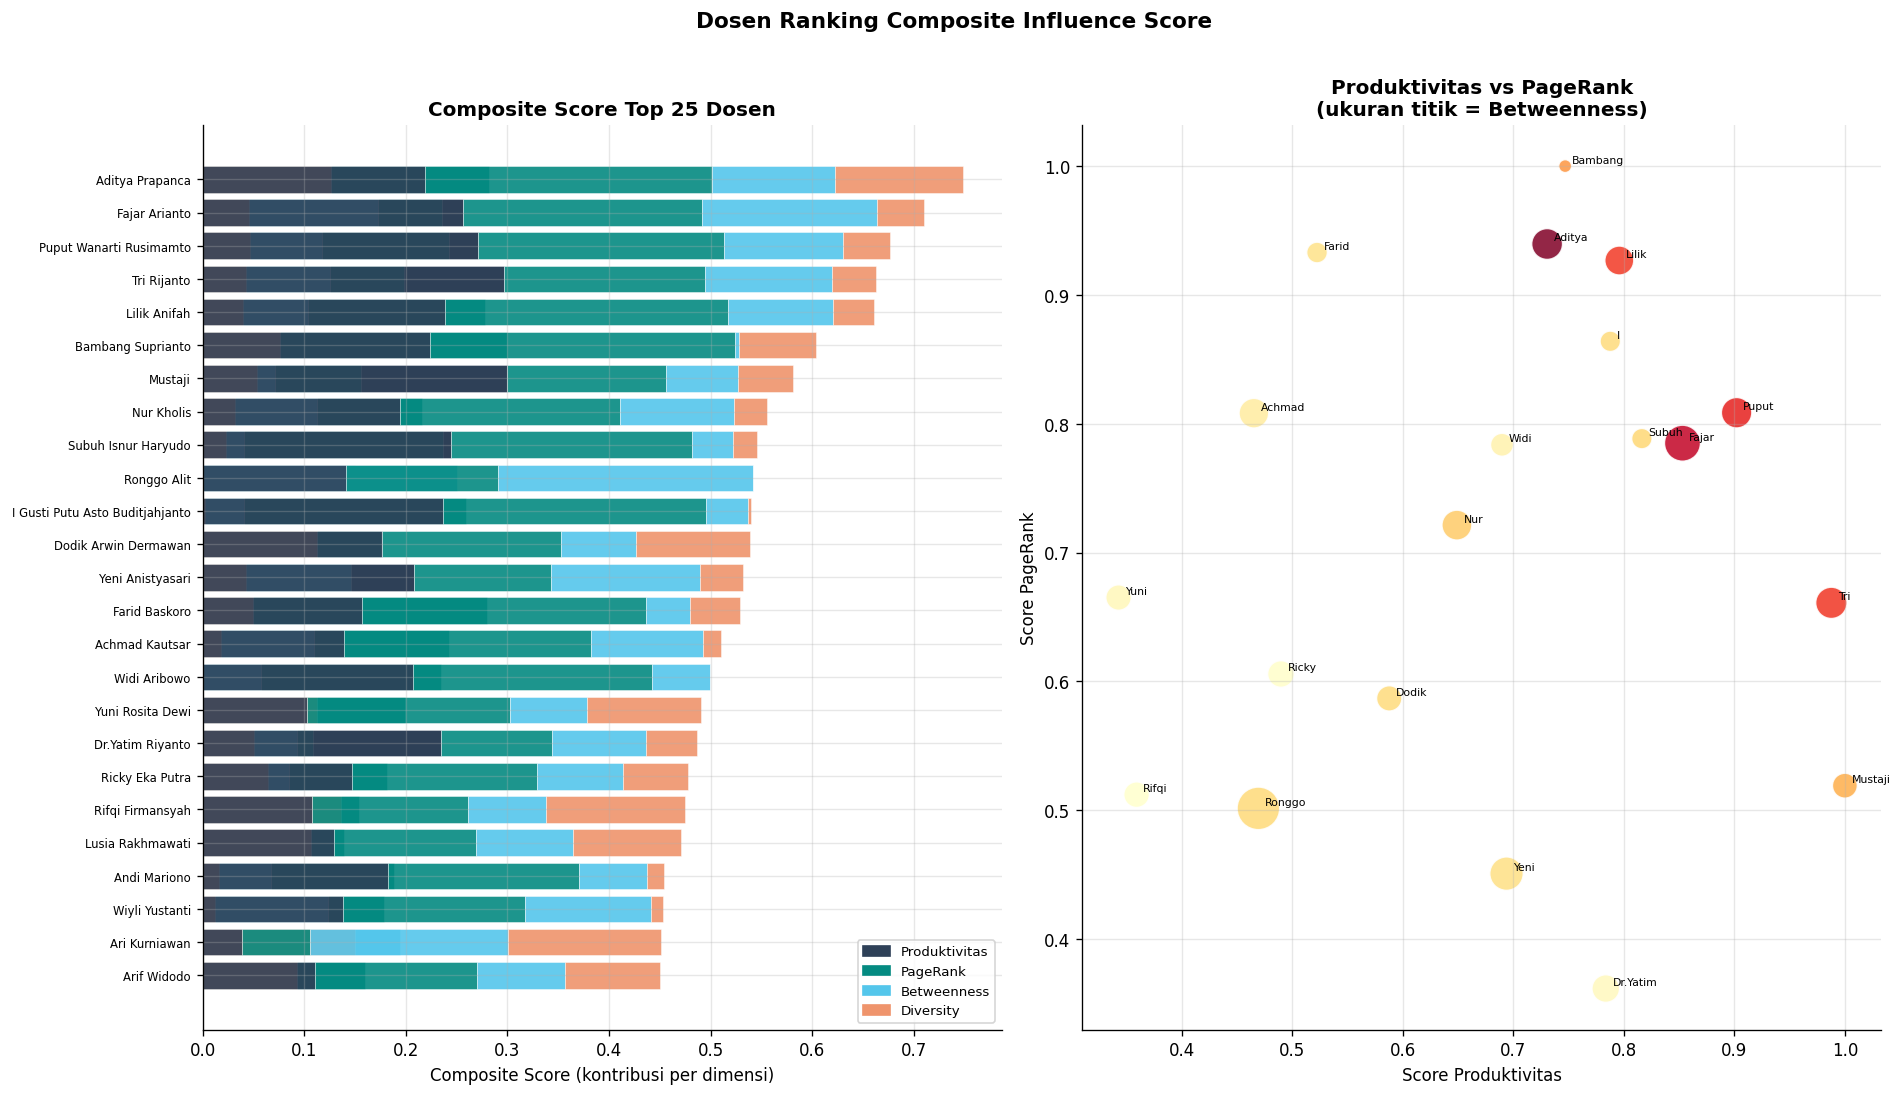

In [45]:
top25 = ranking_df.head(25)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

score_cols  = ['score_produktivitas', 'score_pagerank', 'score_betweenness', 'score_diversity']
score_labels = ['Produktivitas', 'PageRank', 'Betweenness', 'Diversity']
colors_stack = [PALETTE[0], PALETTE[1], PALETTE[2], PALETTE[3]]

bottom = np.zeros(len(top25))
for col, lbl, col_color in zip(score_cols, score_labels, colors_stack):
    vals = top25[col].values
    axes[0].barh(top25['nama_norm_clean'][::-1], vals[::-1] * [W_PROD, W_PR, W_BTW, W_DIV][score_cols.index(col)],
                 left=bottom[::-1] * 0, color=col_color, label=lbl, edgecolor='white', linewidth=0.3)

comp_vals = top25['composite_score'].values
bottom2 = np.zeros(len(top25))
for i, (col, lbl, col_color, w) in enumerate(zip(score_cols, score_labels, colors_stack, [W_PROD, W_PR, W_BTW, W_DIV])):
    contribution = top25[col].values * w
    axes[0].barh(
        range(len(top25)-1, -1, -1),
        contribution,
        left=bottom2,
        color=col_color, label=lbl if i == 0 else '', edgecolor='white', linewidth=0.3,
        alpha=0.9
    )
    bottom2 += contribution

axes[0].set_yticks(range(len(top25)))
axes[0].set_yticklabels(top25['nama_norm_clean'].values[::-1], fontsize=7)
axes[0].set_xlabel('Composite Score (kontribusi per dimensi)')
axes[0].set_title('Composite Score Top 25 Dosen', fontweight='bold')
legend_patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors_stack, score_labels)]
axes[0].legend(handles=legend_patches, fontsize=8, loc='lower right')

ax2_data = ranking_df.head(20)
axes[1].scatter(
    ax2_data['score_produktivitas'],
    ax2_data['score_pagerank'],
    s=ax2_data['score_betweenness'] * 600 + 50,
    c=ax2_data['composite_score'],
    cmap='YlOrRd', alpha=0.85, edgecolors='white', linewidths=0.8
)
for _, row in ax2_data.iterrows():
    axes[1].annotate(
        row['nama_norm_clean'].split()[0],
        (row['score_produktivitas'], row['score_pagerank']),
        fontsize=6.5, xytext=(4, 2), textcoords='offset points'
    )
axes[1].set_xlabel('Score Produktivitas')
axes[1].set_ylabel('Score PageRank')
axes[1].set_title('Produktivitas vs PageRank\n(ukuran titik = Betweenness)', fontweight='bold')

plt.suptitle('Dosen Ranking Composite Influence Score', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ml_plot_08_dosen_ranking.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.1 Radar Chart Profil Multidimensi Top 5 Dosen

Radar chart memperlihatkan keseimbangan empat dimensi untuk masing-masing dosen teratas. Dosen ideal memiliki nilai tinggi di semua dimensi.

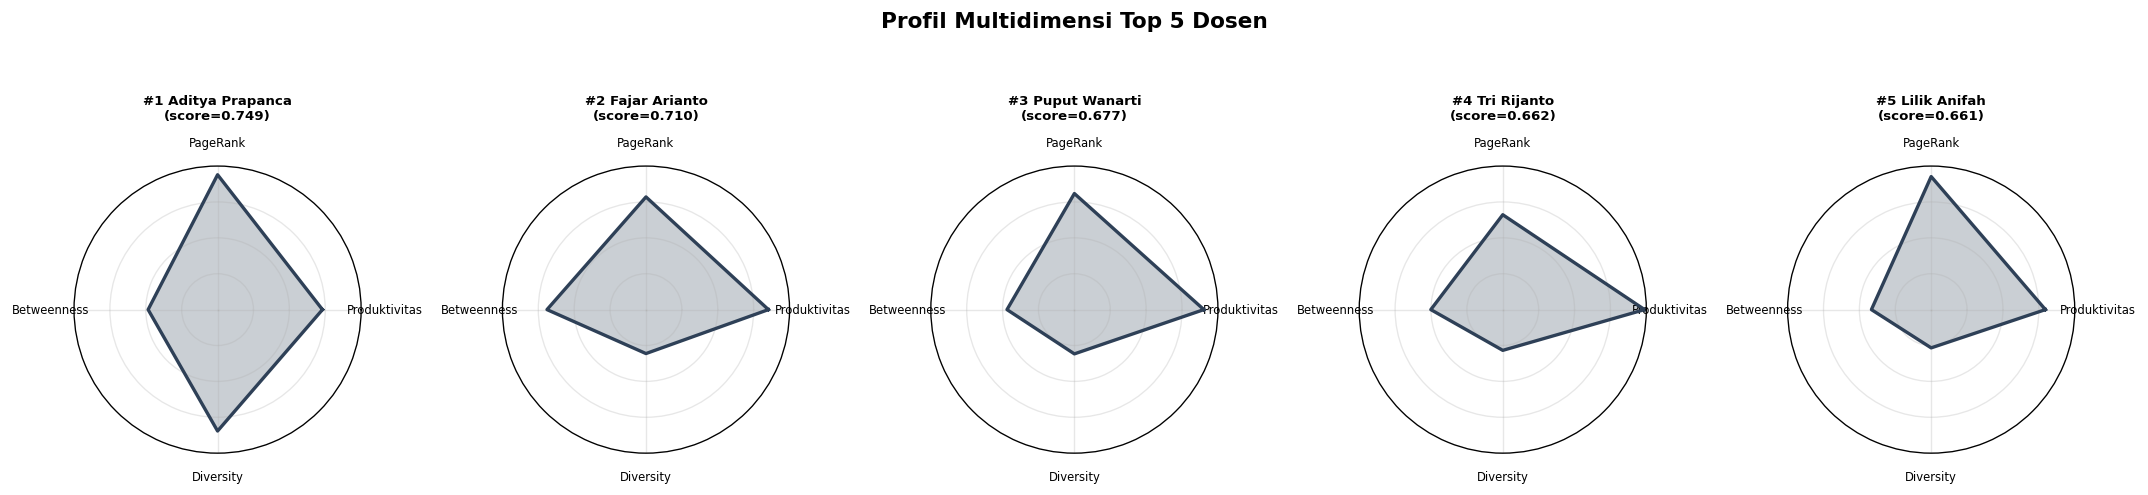

In [47]:
from matplotlib.patches import FancyArrowPatch

top5_radar = ranking_df.head(5)
categories = ['Produktivitas', 'PageRank', 'Betweenness', 'Diversity']
score_keys = ['score_produktivitas', 'score_pagerank', 'score_betweenness', 'score_diversity']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(1, 5, figsize=(18, 4), subplot_kw=dict(polar=True))

for ax, (_, row) in zip(axes, top5_radar.iterrows()):
    values = [row[k] for k in score_keys]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', color=PALETTE[0])
    ax.fill(angles, values, alpha=0.25, color=PALETTE[0])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=7)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['', '', '', ''], size=0)
    name_short = ' '.join(row['nama_norm_clean'].split()[:2])
    ax.set_title(f'#{row["rank"]} {name_short}\n(score={row["composite_score"]:.3f})',
                 size=8, fontweight='bold', pad=10)

plt.suptitle('Profil Multidimensi Top 5 Dosen', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('ml_plot_09_radar_top5.png', bbox_inches='tight', dpi=150)
plt.show()

## FASE 6 Export Hasil ML ke Neo4j

Simpan semua output ML (label cluster, composite score, dominant topic, prediksi kolaborasi) ke dalam graph database Neo4j. Dengan ini, hasil ML bisa di-query langsung menggunakan Cypher.

In [50]:
from neo4j import GraphDatabase

NEO4J_URI      = 'neo4j://127.0.0.1:7687'
NEO4J_USER     = 'neo4j'
NEO4J_PASSWORD = 'infokom2025'

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

try:
    driver.verify_connectivity()
    print('Koneksi ke Neo4j berhasil.')
except Exception as e:
    print(f'Koneksi GAGAL: {e}')

Koneksi ke Neo4j berhasil.


Update properti node Dosen dengan hasil ML: cluster label, composite score, dominant topic, dan PageRank.

In [51]:
ml_records = []
for _, row in ranking_df.iterrows():
    cl_km  = int(cluster_df[cluster_df['nama_norm_clean'] == row['nama_norm_clean']]['cluster_kmeans'].values[0]) \
             if row['nama_norm_clean'] in cluster_df['nama_norm_clean'].values else -1
    cl_sc  = int(cluster_df[cluster_df['nama_norm_clean'] == row['nama_norm_clean']]['cluster_spectral'].values[0]) \
             if row['nama_norm_clean'] in cluster_df['nama_norm_clean'].values else -1
    cl_hdb = int(cluster_df[cluster_df['nama_norm_clean'] == row['nama_norm_clean']]['cluster_hdbscan'].values[0]) \
             if row['nama_norm_clean'] in cluster_df['nama_norm_clean'].values else -1

    ml_records.append({
        'nama'              : row['nama_norm_clean'],
        'cluster_kmeans'    : cl_km,
        'cluster_spectral'  : cl_sc,
        'cluster_hdbscan'   : cl_hdb,
        'composite_score'   : float(row['composite_score']),
        'pagerank'          : float(row['pagerank']) if pd.notna(row['pagerank']) else 0.0,
        'betweenness'       : float(row['betweenness']) if pd.notna(row['betweenness']) else 0.0,
        'dominant_topic'    : int(row['dominant_topic']) if pd.notna(row['dominant_topic']) else 0,
        'topic_entropy'     : float(row['topic_entropy']) if pd.notna(row['topic_entropy']) else 0.0,
        'rank'              : int(row['rank']),
    })

query_update_dosen = '''
UNWIND $rows AS row
MATCH (d:Dosen {nama: row.nama})
SET d.cluster_kmeans   = row.cluster_kmeans,
    d.cluster_spectral = row.cluster_spectral,
    d.cluster_hdbscan  = row.cluster_hdbscan,
    d.composite_score  = row.composite_score,
    d.pagerank         = row.pagerank,
    d.betweenness      = row.betweenness,
    d.dominant_topic   = row.dominant_topic,
    d.topic_entropy    = row.topic_entropy,
    d.influence_rank   = row.rank
'''

def batch_run(session, query, data, batch_size=100):
    total = 0
    for i in range(0, len(data), batch_size):
        session.run(query, rows=data[i:i+batch_size])
        total += len(data[i:i+batch_size])
    return total

with driver.session() as session:
    n = batch_run(session, query_update_dosen, ml_records)
    print(f'Berhasil update {n} node Dosen dengan hasil ML.')

Berhasil update 126 node Dosen dengan hasil ML.


Simpan top prediksi kolaborasi ke Neo4j sebagai relationship `PREDICTED_COLLAB`.

In [52]:
top_pred = pred_df.head(100)

pred_records = [
    {
        'dosen_a'         : row['dosen_a'],
        'dosen_b'         : row['dosen_b'],
        'prob'            : float(row['prob_kolaborasi']),
        'common_n'        : int(row['common_neighbors']),
        'topic_sim'       : float(row['topic_similarity']),
    }
    for _, row in top_pred.iterrows()
]

query_pred = '''
UNWIND $rows AS row
MATCH (a:Dosen {nama: row.dosen_a})
MATCH (b:Dosen {nama: row.dosen_b})
MERGE (a)-[r:PREDICTED_COLLAB]-(b)
SET r.probability      = row.prob,
    r.common_neighbors = row.common_n,
    r.topic_similarity = row.topic_sim
'''

with driver.session() as session:
    n = batch_run(session, query_pred, pred_records)
    print(f'Berhasil simpan {n} prediksi kolaborasi ke Neo4j.')

driver.close()
print('Koneksi Neo4j ditutup.')

Berhasil simpan 100 prediksi kolaborasi ke Neo4j.
Koneksi Neo4j ditutup.


### 6.1 Verifikasi Query Neo4j

Beberapa query Cypher yang bisa dijalankan di Neo4j Browser untuk memanfaatkan hasil ML:

In [ ]:
print('''
=== QUERY CYPHER YANG BISA DICOBA DI NEO4J BROWSER ===

// Top 10 dosen berdasarkan composite influence score
MATCH (d:Dosen)
WHERE d.composite_score IS NOT NULL
RETURN d.nama, d.composite_score, d.influence_rank, d.dominant_topic
ORDER BY d.composite_score DESC LIMIT 10

// Lihat semua dosen dalam satu cluster K-Means
MATCH (d:Dosen)
WHERE d.cluster_kmeans = 0
RETURN d.nama, d.prodi, d.composite_score, d.dominant_topic
ORDER BY d.composite_score DESC

// Visualisasi prediksi kolaborasi dengan probabilitas tinggi
MATCH (a:Dosen)-[r:PREDICTED_COLLAB]-(b:Dosen)
WHERE r.probability > 0.7
RETURN a, r, b

// Siapa dosen yang paling sering diprediksi akan berkolaborasi?
MATCH (d:Dosen)-[r:PREDICTED_COLLAB]-(other:Dosen)
WHERE r.probability > 0.5
RETURN d.nama, count(other) AS potensi_mitra, avg(r.probability) AS avg_prob
ORDER BY potensi_mitra DESC LIMIT 10

// Dosen dalam cluster yang sama dengan topic similarity tinggi
MATCH (a:Dosen)-[r:PREDICTED_COLLAB]-(b:Dosen)
WHERE a.cluster_kmeans = b.cluster_kmeans AND r.topic_similarity > 0.8
RETURN a.nama, b.nama, r.probability, r.topic_similarity
ORDER BY r.probability DESC LIMIT 15
''')

## FASE 7 Ringkasan & Export Hasil

Export semua hasil ke file CSV agar mudah digunakan oleh dashboard Streamlit.

In [49]:
final_dosen_df = ranking_df.merge(
    cluster_df[['nama_norm_clean','cluster_kmeans','cluster_spectral','cluster_hdbscan']],
    on='nama_norm_clean', how='left'
)
final_dosen_df = final_dosen_df.merge(
    topic_df[['nama_norm_clean'] + [f'topic_{i+1}' for i in range(best_k)]],
    on='nama_norm_clean', how='left'
)

final_dosen_df.to_csv('ml_output_dosen_profiles.csv', index=False)
pred_df.head(200).to_csv('ml_output_link_predictions.csv', index=False)
topic_df.to_csv('ml_output_topic_distribution.csv', index=False)

lda_topics_export = []
for i in range(best_k):
    words = lda_final.show_topic(i, topn=10)
    lda_topics_export.append({
        'topic_id'   : i + 1,
        'top_words'  : ', '.join([w for w, _ in words]),
        'top_weights': ', '.join([f'{p:.4f}' for _, p in words])
    })
pd.DataFrame(lda_topics_export).to_csv('ml_output_lda_topics.csv', index=False)

print('RINGKASAN AKHIR')
print(f'  Total dosen dianalisis   : {len(final_dosen_df)}')
print(f'  Jumlah topik LDA         : {best_k} (coherence={coherence_scores[best_k]:.4f})')
print(f'  Cluster terbaik          : {winner}')
print(f'    K-Means K              : {best_k_km} (Silhouette={kmeans_results[best_k_km]["silhouette"]:.4f})')
print(f'    Spectral K             : {best_k_sc} (Silhouette={spectral_results[best_k_sc]["silhouette"]:.4f})')
print(f'    HDBSCAN min_size       : {best_ms} (Clusters={hdbscan_results[best_ms]["n_clusters"]})')
print(f'  Link prediction terbaik  : {best_lp_model_name} (AUC={max(rf_auc_scores.mean(), xgb_auc_scores.mean()):.4f})')
print(f'  Total prediksi digenerate: {len(pred_df)}')
print(f'  Dosen #1 composite score : {ranking_df.iloc[0]["nama_norm_clean"]} ({ranking_df.iloc[0]["composite_score"]:.4f})')
print()
print('File output yang dihasilkan:')
for f in ['ml_output_dosen_profiles.csv','ml_output_link_predictions.csv','ml_output_topic_distribution.csv','ml_output_lda_topics.csv']:
    print(f'  {f}')
for i in range(1, 10):
    print(f'  ml_plot_{i:02d}_*.png')

RINGKASAN AKHIR
  Total dosen dianalisis   : 126
  Jumlah topik LDA         : 12 (coherence=0.5905)
  Cluster terbaik          : HDBSCAN
    K-Means K              : 11 (Silhouette=0.2883)
    Spectral K             : 10 (Silhouette=0.2724)
    HDBSCAN min_size       : 4 (Clusters=9)
  Link prediction terbaik  : Random Forest (AUC=0.8640)
  Total prediksi digenerate: 6690
  Dosen #1 composite score : Aditya Prapanca (0.7488)

File output yang dihasilkan:
  ml_output_dosen_profiles.csv
  ml_output_link_predictions.csv
  ml_output_topic_distribution.csv
  ml_output_lda_topics.csv
  ml_plot_01_*.png
  ml_plot_02_*.png
  ml_plot_03_*.png
  ml_plot_04_*.png
  ml_plot_05_*.png
  ml_plot_06_*.png
  ml_plot_07_*.png
  ml_plot_08_*.png
  ml_plot_09_*.png
